## Historical trnd analysis, category-wise

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('monthly_demand_clean.csv', index_col=0, parse_dates=True)
df.head()

,CPU,Mother Board,RAM,Storage,Video Card
2013-06-01,NaN,NaN,NaN,119.0,NaN
2013-07-01,NaN,NaN,NaN,0.0,NaN
2013-08-01,NaN,NaN,NaN,0.0,NaN
2013-09-01,NaN,NaN,NaN,0.0,NaN
2013-10-01,NaN,NaN,NaN,0.0,NaN


In [2]:
summary = df.agg(['mean', 'std', 'min', 'max', 'sum']).T
summary['growth_%'] = ((df.iloc[-6:].mean() - df.iloc[:6].mean()) / df.iloc[:6].mean() * 100)
summary

,mean,std,min,max,sum,growth_%
CPU,156.483871,178.724531,0.0,584.0,4851.0,NaN
Mother Board,92.903226,135.261809,0.0,557.0,2880.0,NaN
RAM,44.037037,84.022653,0.0,334.0,1189.0,NaN
Storage,91.537037,164.276425,0.0,870.0,4943.0,297.478992
Video Card,95.612903,108.023663,0.0,351.0,2964.0,NaN


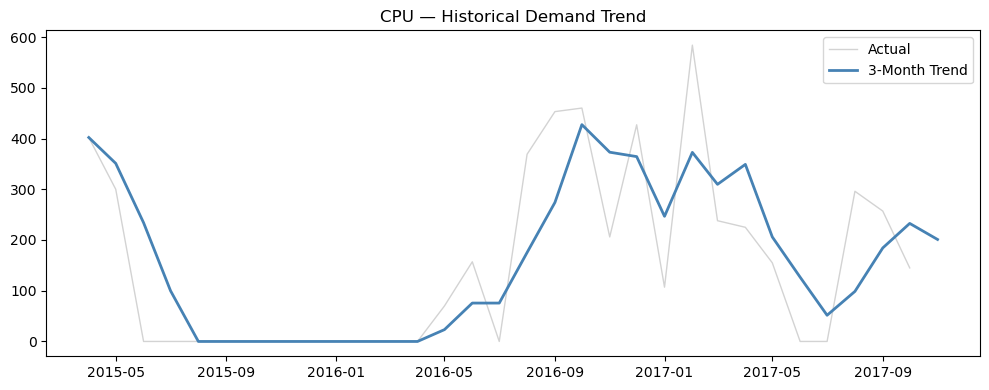

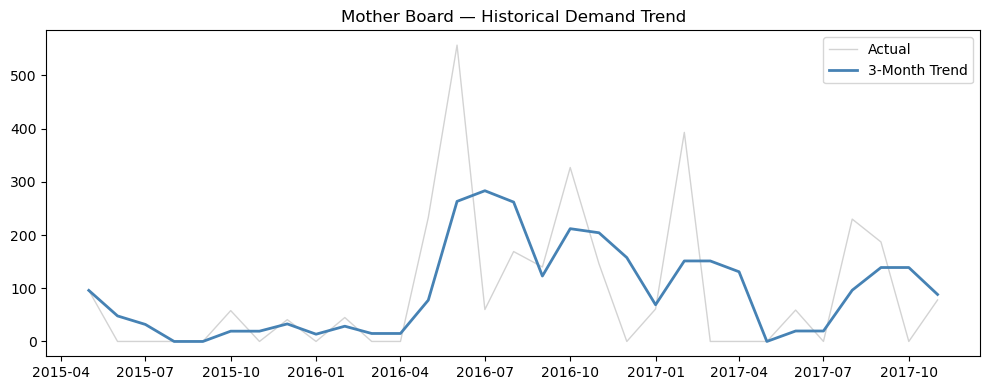

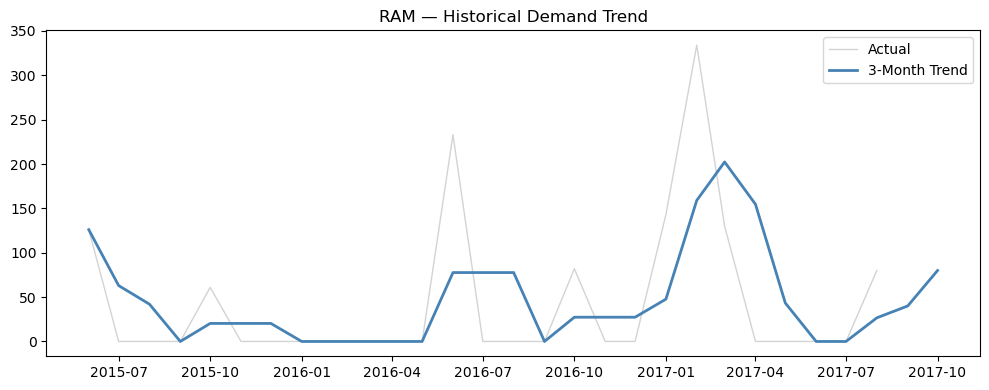

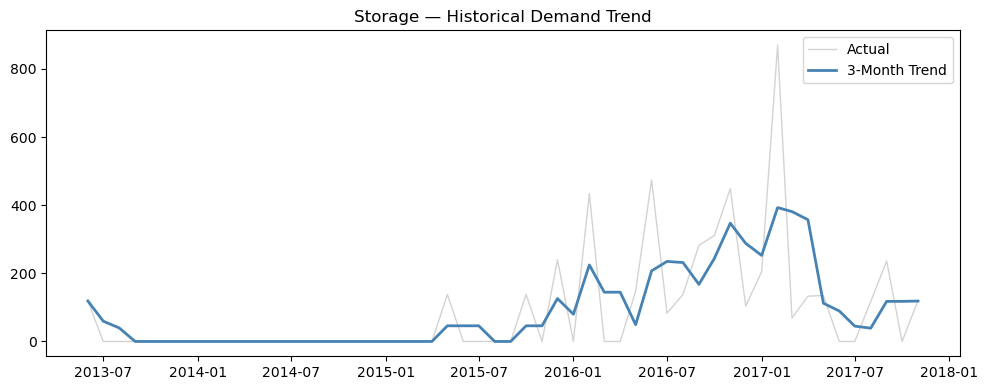

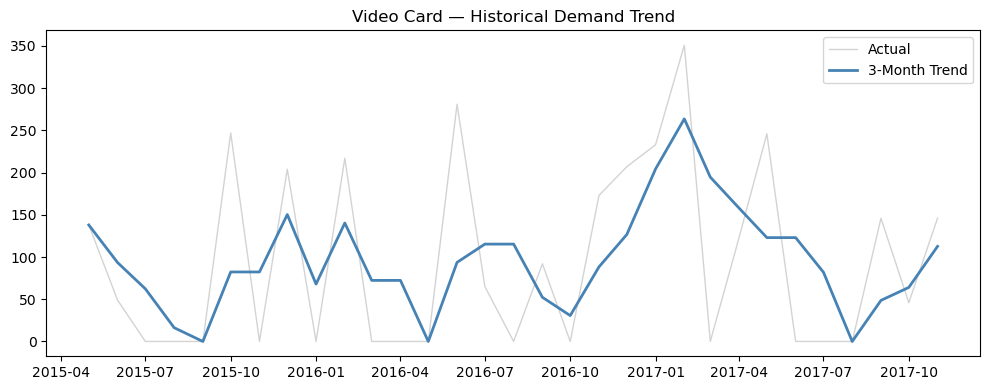

In [3]:
for cat in df.columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(df.index, df[cat], color='lightgray', label='Actual', linewidth=1)
    ax.plot(df.index, df[cat].rolling(3, min_periods=1).mean(), color='steelblue', label='3-Month Trend', linewidth=2)
    ax.set_title(f'{cat} — Historical Demand Trend')
    ax.legend()
    plt.tight_layout()
    plt.show()

## Train/Test Split for Time-Series Visualization

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('monthly_demand_clean.csv', index_col=0, parse_dates=True)

n = len(df)
test_size = int(n * 0.2)          # 20% held out for testing
split_idx = n - test_size
split_date = df.index[split_idx]

train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

print(f"Split date: {split_date.date()}")
print(f"Train shape: {train.shape}, Test shape: {test.shape}")

Split date: 2017-02-01
Train shape: (44, 5), Test shape: (10, 5)


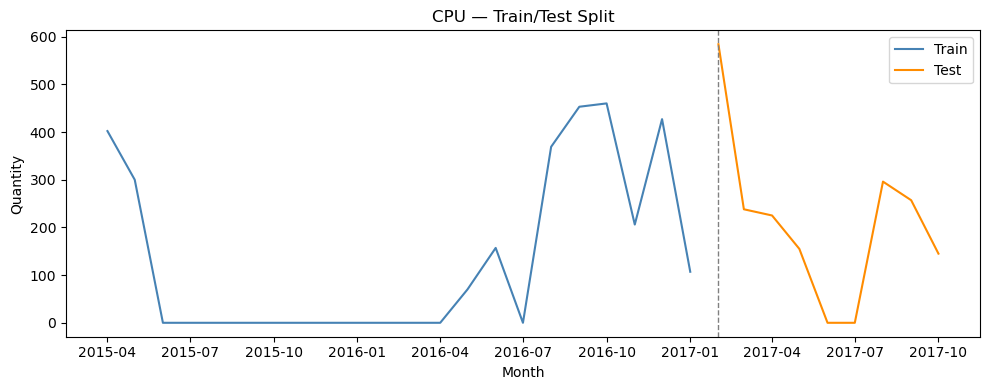

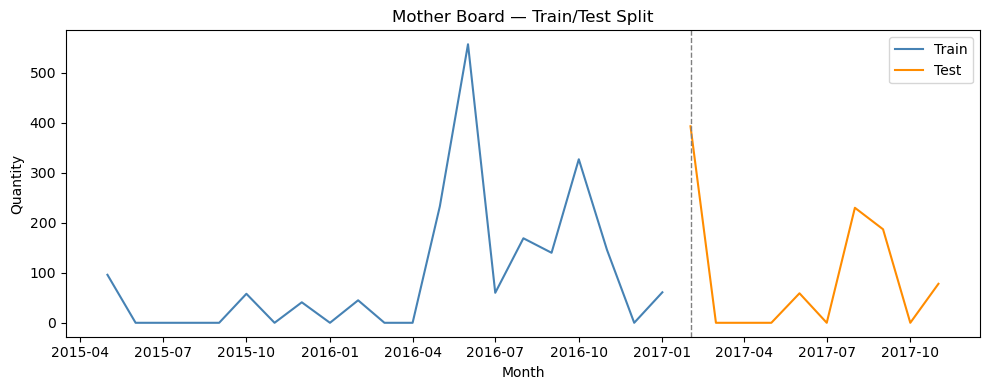

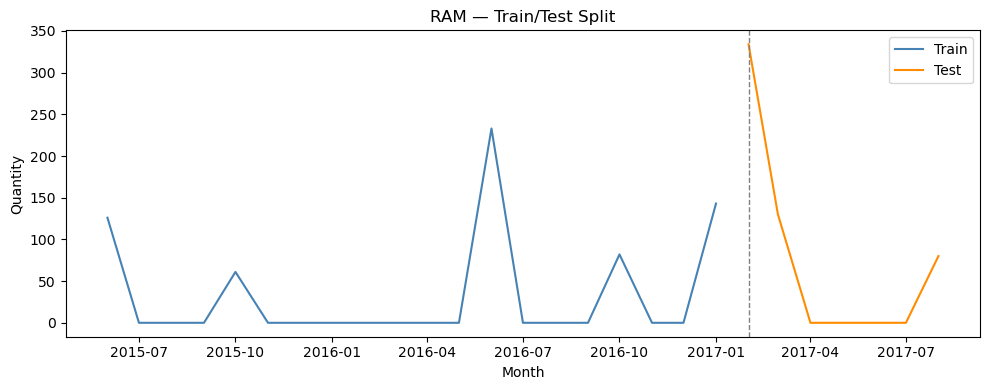

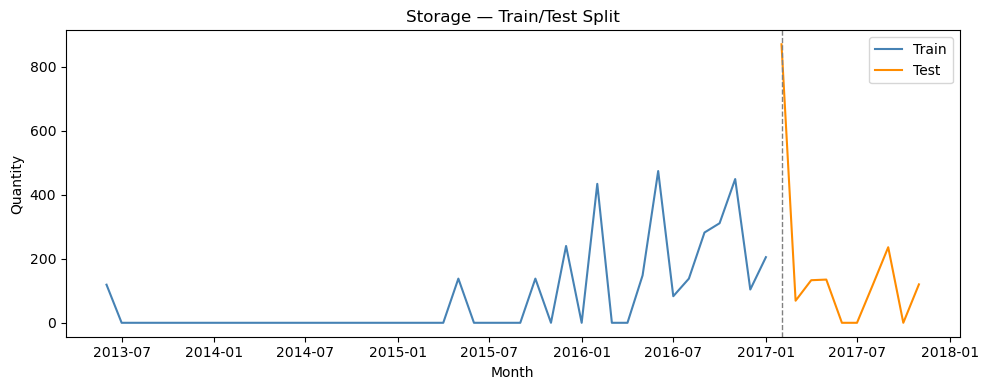

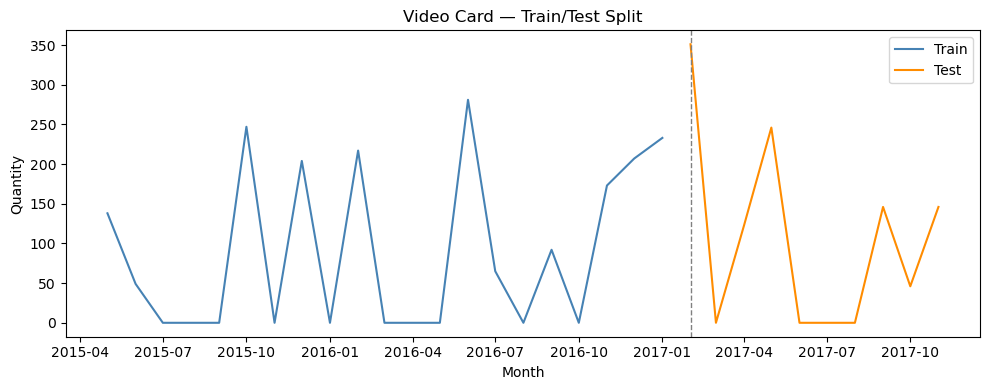

In [5]:
for cat in df.columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(train.index, train[cat], color='steelblue', label='Train', linewidth=1.5)
    ax.plot(test.index, test[cat], color='darkorange', label='Test', linewidth=1.5)
    ax.axvline(split_date, color='gray', linestyle='--', linewidth=1)
    ax.set_title(f'{cat} — Train/Test Split')
    ax.set_xlabel('Month')
    ax.set_ylabel('Quantity')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [6]:
import os
os.makedirs('figures', exist_ok=True)

for cat in df.columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(train.index, train[cat], color='steelblue', label='Train', linewidth=1.5)
    ax.plot(test.index, test[cat], color='darkorange', label='Test', linewidth=1.5)
    ax.axvline(split_date, color='gray', linestyle='--', linewidth=1)
    ax.set_title(f'{cat} — Train/Test Split')
    ax.legend()
    fig.tight_layout()
    safe_name = cat.lower().replace(' ', '_')
    fig.savefig(f'figures/{safe_name}_train_test.png', dpi=150)
    plt.close(fig)

print(os.listdir('figures'))

['cpu_baseline.png', 'cpu_train_test.png', 'cpu_trend.png', 'monthly_demand_overview.png', 'mother_board_baseline.png', 'mother_board_train_test.png', 'mother_board_trend.png', 'ram_baseline.png', 'ram_train_test.png', 'ram_trend.png', 'storage_baseline.png', 'storage_train_test.png', 'storage_trend.png', 'video_card_baseline.png', 'video_card_train_test.png', 'video_card_trend.png']


In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv('monthly_demand_clean.csv', index_col=0, parse_dates=True)

n = len(df)
test_size = int(n * 0.2)
split_idx = n - test_size
train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

window = 3   # 3-month moving average — same idea as your Day 24 trend line

baseline_forecast = {}
for cat in df.columns:
    history = train[cat].copy()
    preds = []
    for actual_value in test[cat]:
        pred = history.tail(window).mean()   # avg of last 3 known months
        preds.append(pred)
        history = pd.concat([history, pd.Series([actual_value])])   # "actual" becomes known for next step
    baseline_forecast[cat] = preds

baseline_df = pd.DataFrame(baseline_forecast, index=test.index)
baseline_df.head()

,CPU,Mother Board,RAM,Storage,Video Card
2017-02-01,246.666667,69.000000,47.666667,252.666667,204.333333
2017-03-01,372.666667,151.333333,159.000000,393.000000,263.666667
2017-04-01,309.666667,151.333333,202.333333,381.333333,194.666667
2017-05-01,349.000000,131.000000,154.666667,357.333333,158.000000
2017-06-01,206.000000,0.000000,43.333333,112.333333,123.000000


In [8]:
error_summary = {}
for cat in df.columns:
    valid = test[cat].notna()   # only compare where actual data exists
    mae = np.mean(np.abs(test[cat][valid].values - baseline_df[cat][valid].values))
    error_summary[cat] = round(mae, 1)

error_df = pd.Series(error_summary, name='MAE').sort_values(ascending=False)
print(error_df)

Storage         200.3
CPU             169.5
Mother Board    133.7
RAM             113.7
Video Card      112.9
Name: MAE, dtype: float64


Storage         200.3
CPU             169.5
Mother Board    133.7
RAM             113.7
Video Card      112.9
Name: MAE, dtype: float64


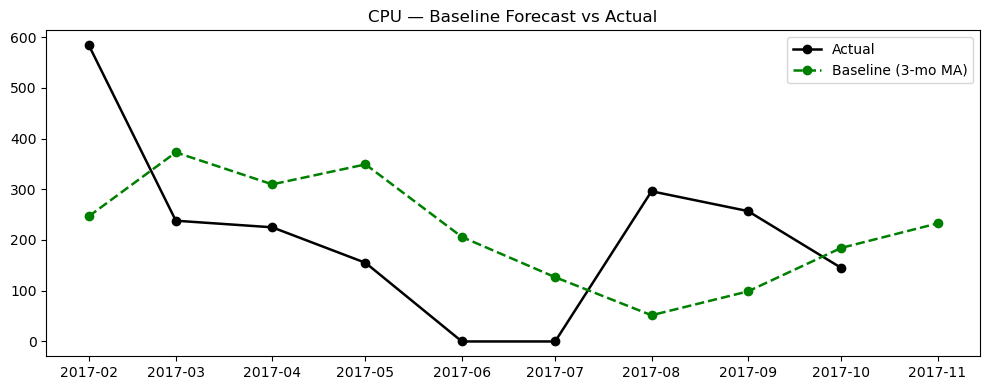

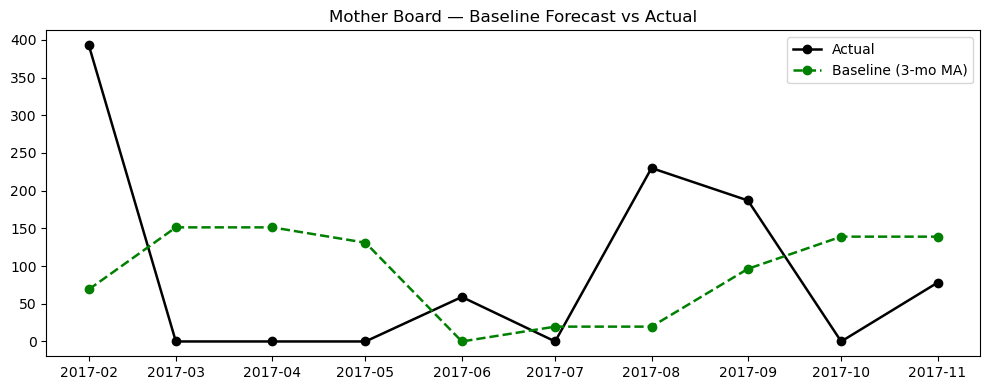

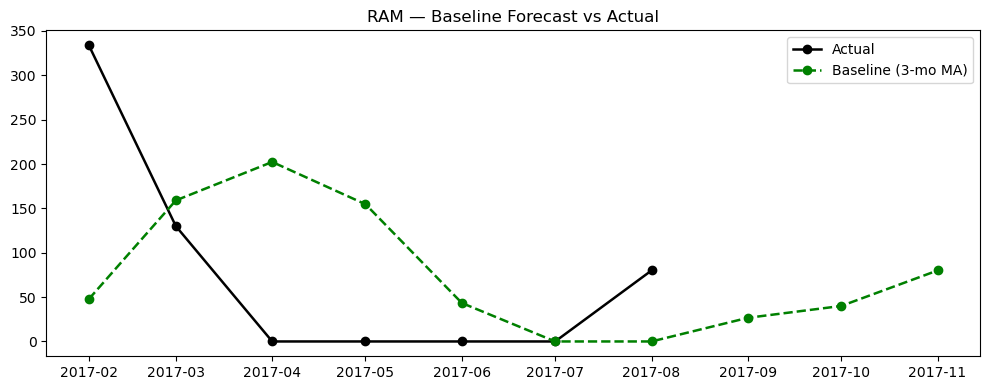

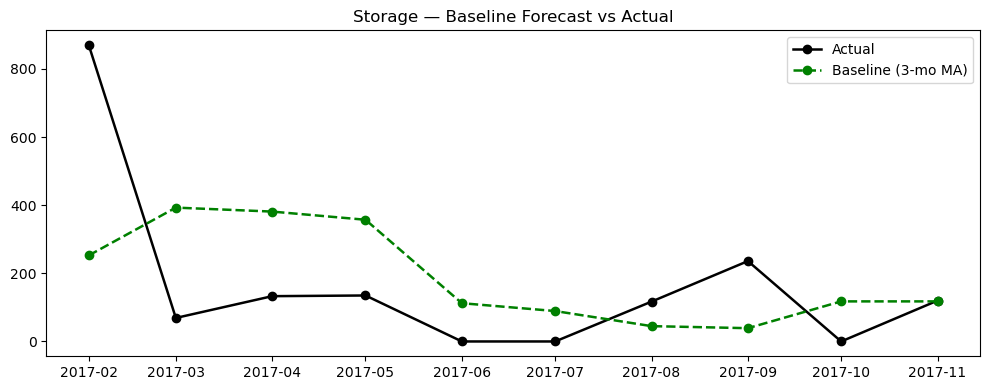

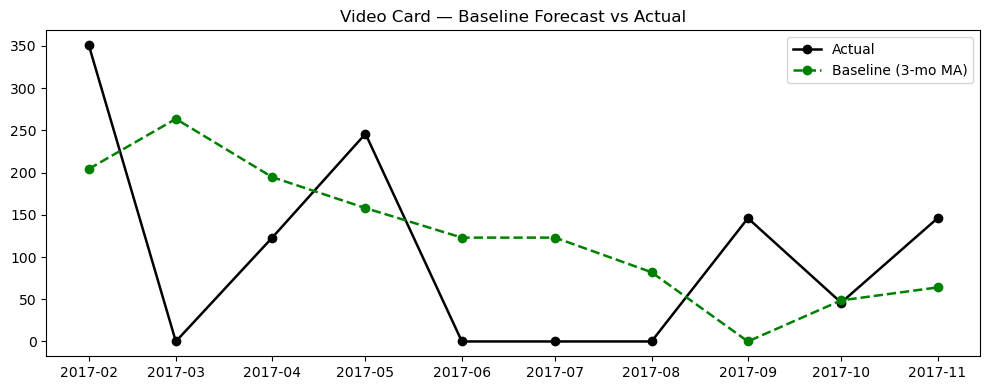

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

df = pd.read_csv('monthly_demand_clean.csv', index_col=0, parse_dates=True)

n = len(df)
test_size = int(n * 0.2)
split_idx = n - test_size
train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

# Walk-forward 3-month moving average baseline
window = 3
baseline_forecast = {}
for cat in df.columns:
    history = train[cat].copy()
    preds = []
    for actual_value in test[cat]:
        pred = history.tail(window).mean()
        preds.append(pred)
        history = pd.concat([history, pd.Series([actual_value])])
    baseline_forecast[cat] = preds

baseline_df = pd.DataFrame(baseline_forecast, index=test.index)

# MAE, skipping months with missing actual data
error_summary = {}
for cat in df.columns:
    valid = test[cat].notna()
    mae = np.mean(np.abs(test[cat][valid].values - baseline_df[cat][valid].values))
    error_summary[cat] = round(mae, 1)

error_df = pd.Series(error_summary, name='MAE').sort_values(ascending=False)
print(error_df)

# Plot + save each category
os.makedirs('figures', exist_ok=True)
for cat in df.columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(test.index, test[cat], color='black', label='Actual', linewidth=1.8, marker='o')
    ax.plot(test.index, baseline_df[cat], color='green', linestyle='--', label='Baseline (3-mo MA)', linewidth=1.8, marker='o')
    ax.set_title(f'{cat} — Baseline Forecast vs Actual')
    ax.legend()
    plt.tight_layout()
    safe_name = cat.lower().replace(' ', '_')
    fig.savefig(f'figures/{safe_name}_baseline.png', dpi=150)
    plt.show()

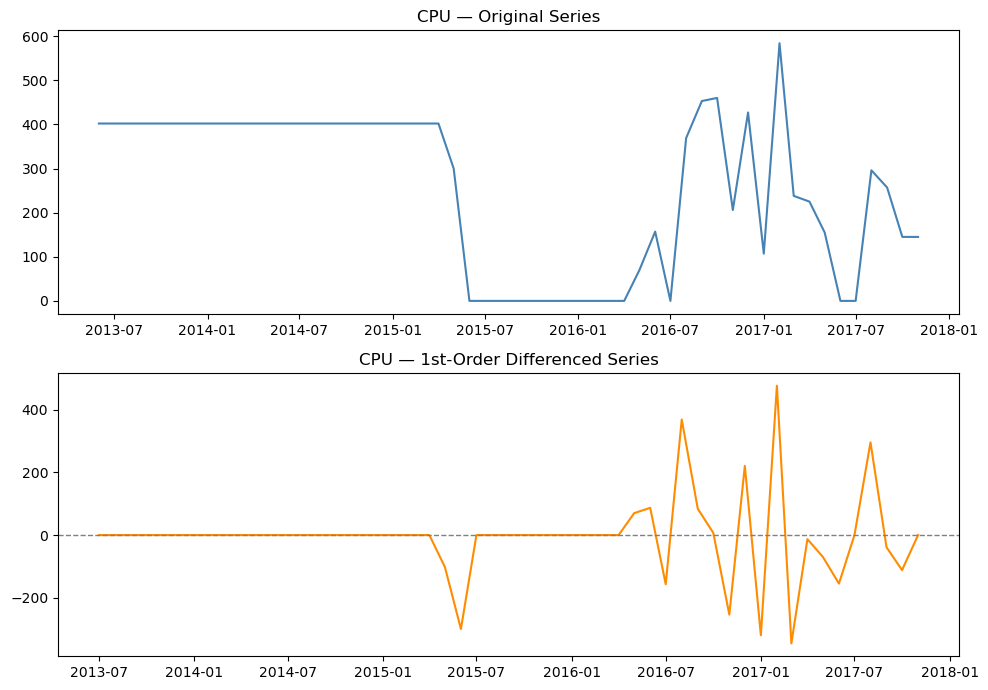

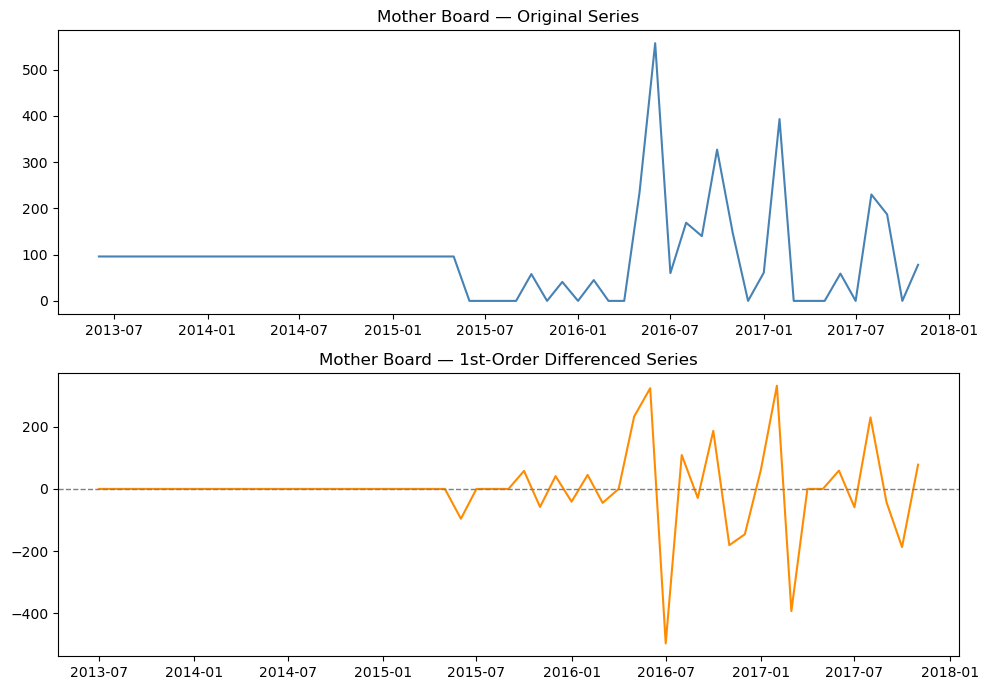

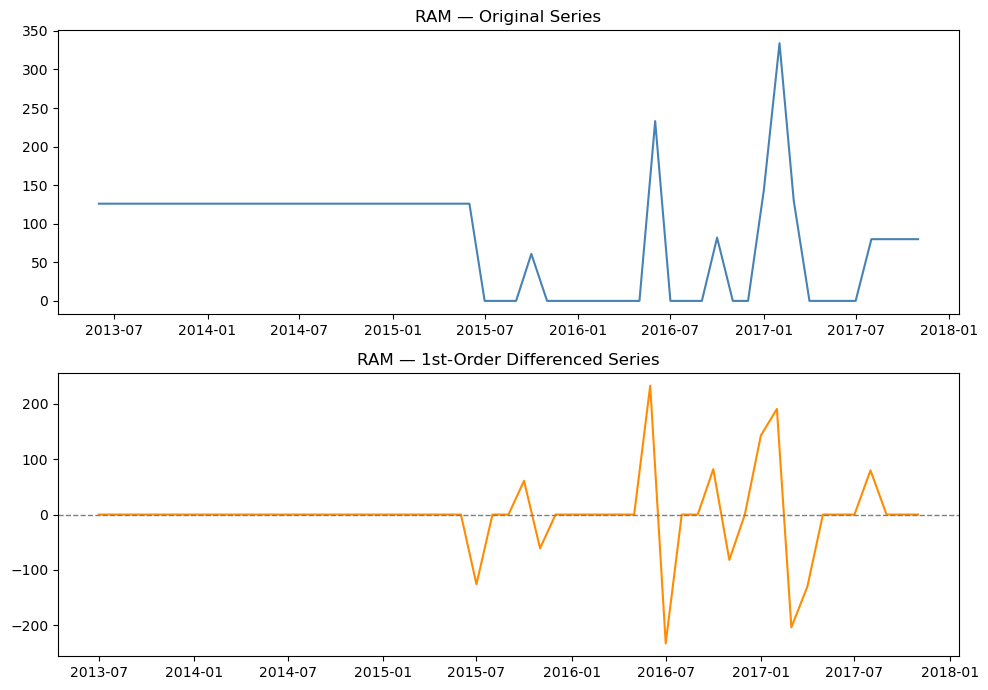

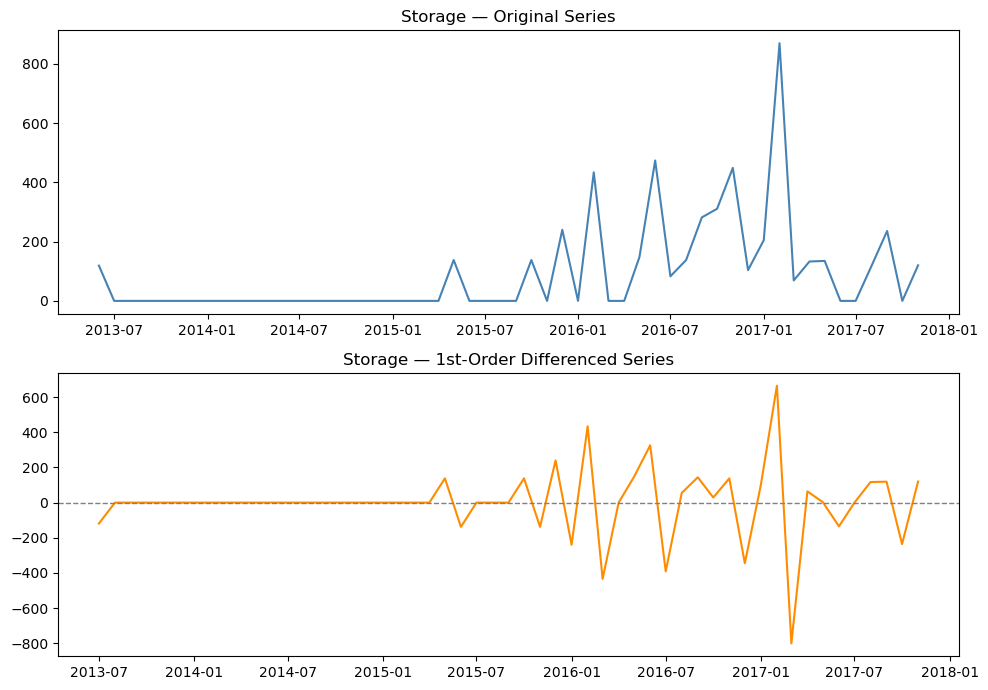

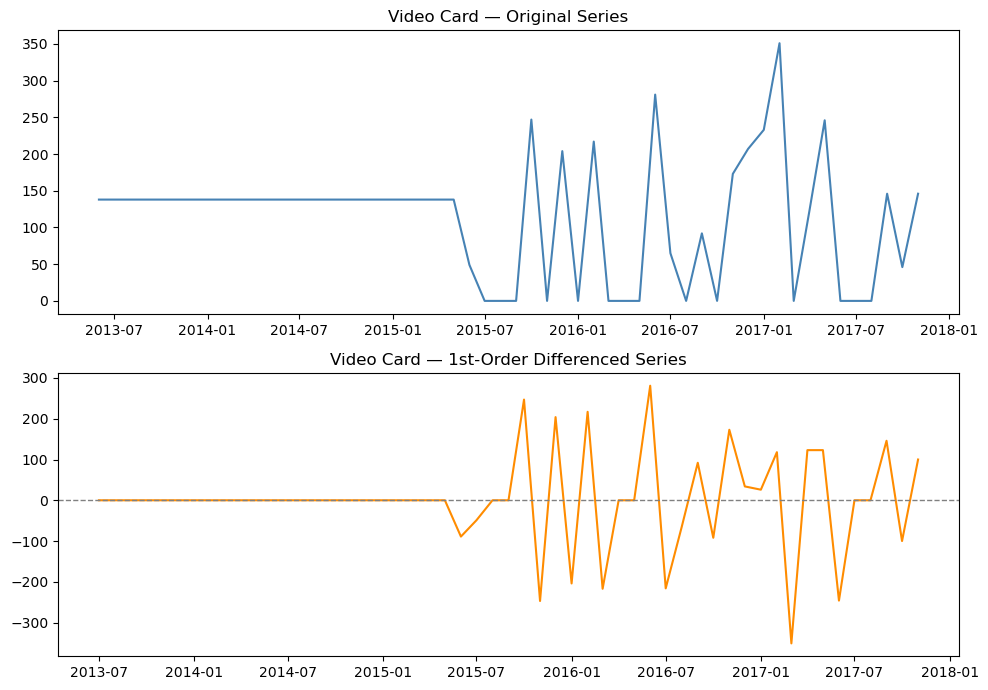

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('forecasting_ready_data.csv', parse_dates=['OrderDate'])
wide = df.pivot(index='OrderDate', columns='CategoryName', values='Quantity')

for cat in wide.columns:
    series = wide[cat]
    diff = series.diff().dropna()   # subtract each month from the previous one

    fig, axes = plt.subplots(2, 1, figsize=(10, 7))
    axes[0].plot(series.index, series.values, color='steelblue')
    axes[0].set_title(f'{cat} — Original Series')
    axes[1].plot(diff.index, diff.values, color='darkorange')
    axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
    axes[1].set_title(f'{cat} — 1st-Order Differenced Series')
    plt.tight_layout()
    plt.show()

C:\Users\ASUS\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ASUS\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ASUS\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ASUS\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ASUS\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self.

              Baseline_MAE  ARIMA_MAE Better_Model
CPU                  169.5      131.3        ARIMA
Mother Board         133.7      115.8        ARIMA
RAM                  113.7       84.7        ARIMA
Storage              200.3      191.0        ARIMA
Video Card           112.9      101.4        ARIMA


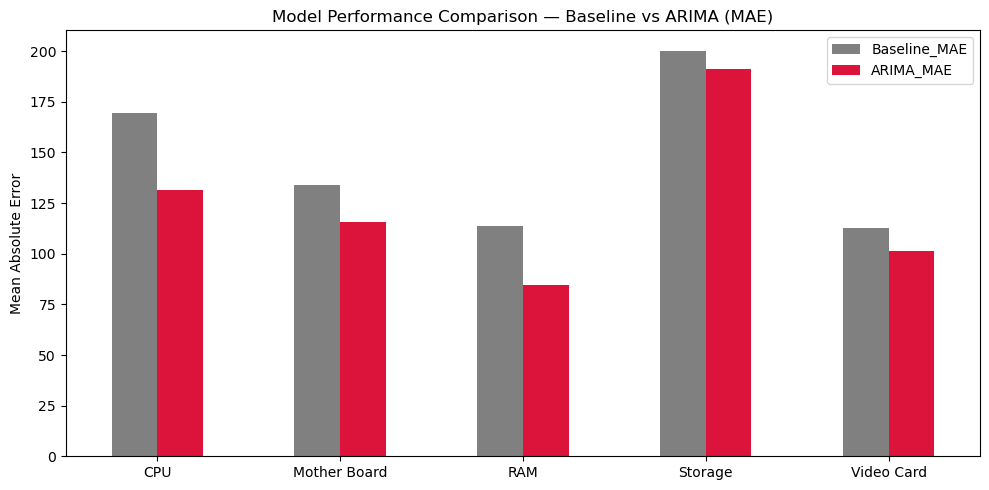

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.arima.model import ARIMA

df = pd.read_csv('monthly_demand_clean.csv', index_col=0, parse_dates=True)
n = len(df)
test_size = int(n * 0.2)
split_idx = n - test_size
train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

# --- Baseline MAE (Day 26) ---
window = 3
baseline_forecast = {}
for cat in df.columns:
    history = train[cat].copy()
    preds = []
    for actual_value in test[cat]:
        pred = history.tail(window).mean()
        preds.append(pred)
        history = pd.concat([history, pd.Series([actual_value])])
    baseline_forecast[cat] = preds
baseline_df = pd.DataFrame(baseline_forecast, index=test.index)

# --- ARIMA MAE (placeholder — replace with Member 2's real forecast when available) ---
baseline_mae = {}
arima_mae = {}
for cat in df.columns:
    valid = test[cat].notna()
    baseline_mae[cat] = round(np.mean(np.abs(test[cat][valid].values - baseline_df[cat][valid].values)), 1)

    train_series = train[cat].fillna(0)
    model = ARIMA(train_series, order=(1,1,1))
    fit = model.fit()
    forecast = fit.forecast(steps=len(test))
    forecast.index = test.index
    arima_mae[cat] = round(np.mean(np.abs(test[cat][valid].values - forecast[valid].values)), 1)

comparison = pd.DataFrame({'Baseline_MAE': baseline_mae, 'ARIMA_MAE': arima_mae})
comparison['Better_Model'] = comparison.apply(
    lambda r: 'ARIMA' if r['ARIMA_MAE'] < r['Baseline_MAE'] else 'Baseline', axis=1
)
print(comparison)

# --- Chart ---
fig, ax = plt.subplots(figsize=(10, 5))
comparison[['Baseline_MAE', 'ARIMA_MAE']].plot(kind='bar', ax=ax, color=['gray', 'crimson'])
ax.set_title('Model Performance Comparison — Baseline vs ARIMA (MAE)')
ax.set_ylabel('Mean Absolute Error')
ax.set_xticklabels(comparison.index, rotation=0)
plt.tight_layout()
plt.savefig('figures/model_comparison.png', dpi=150)
plt.show()

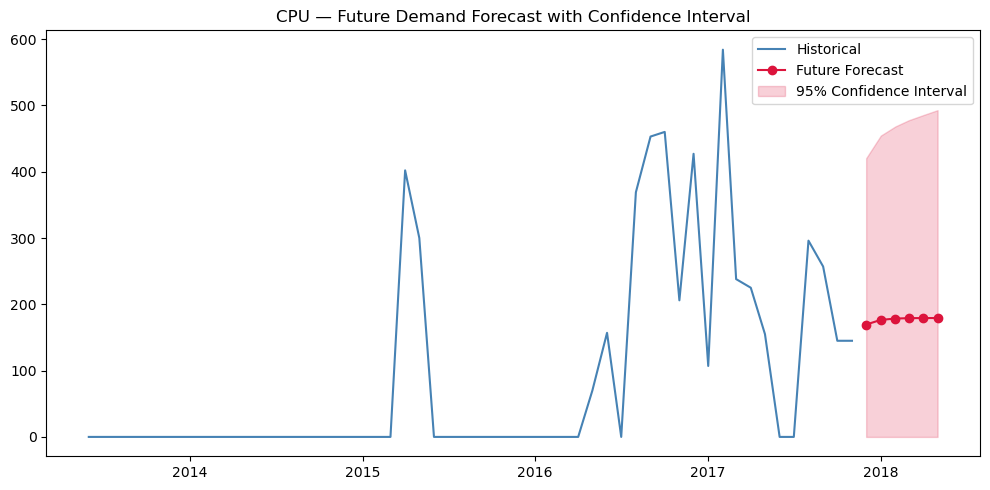

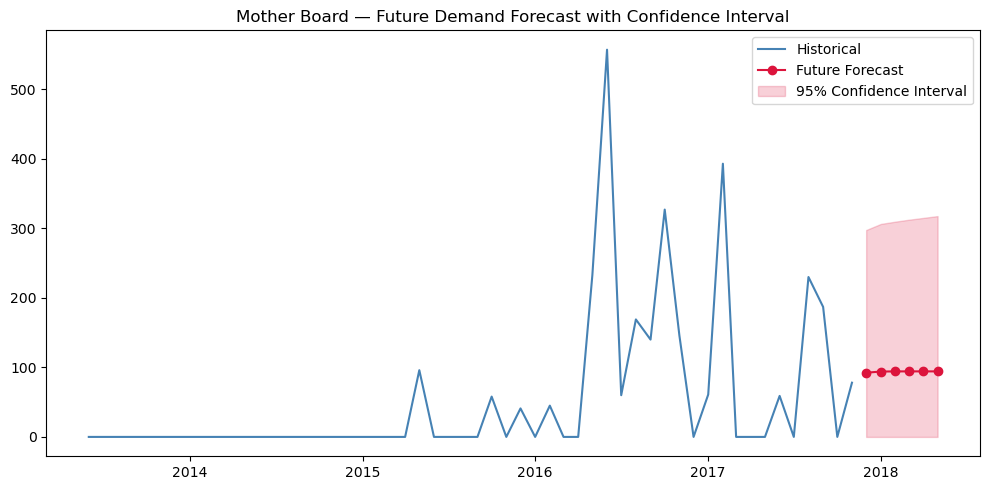

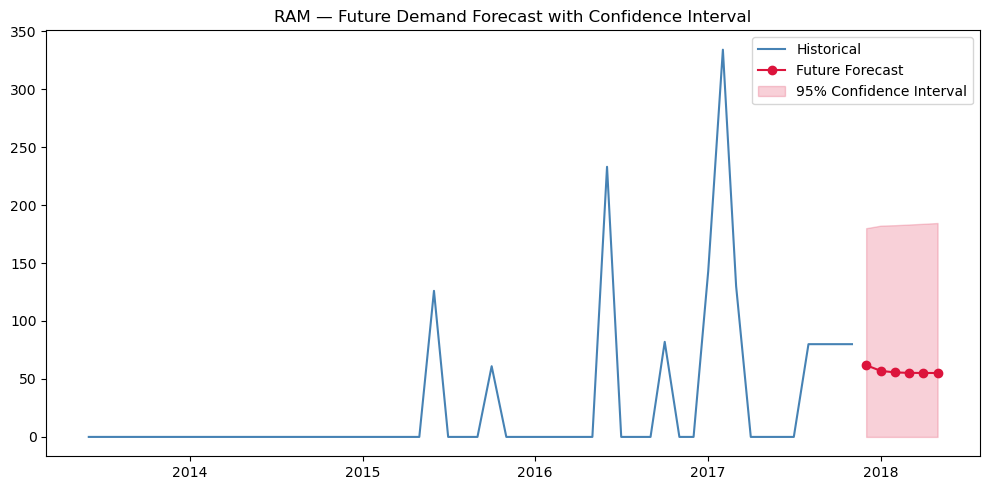

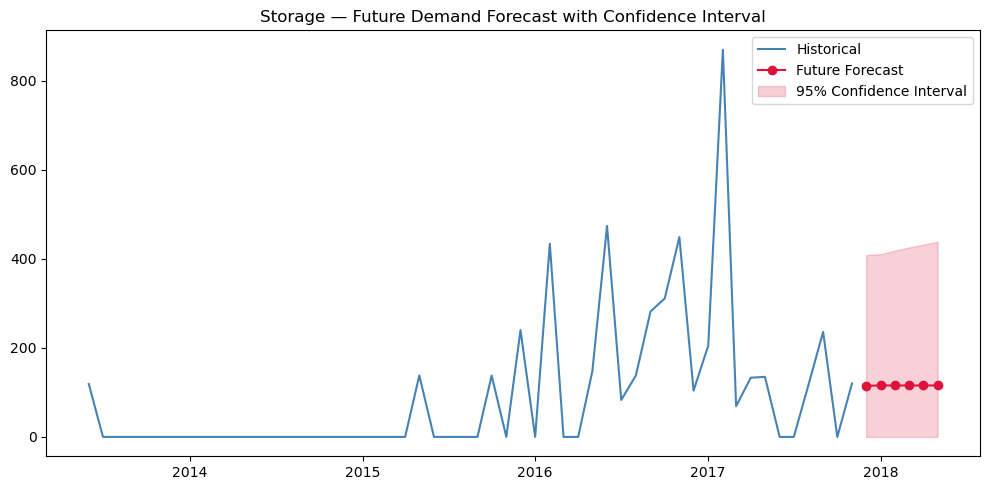

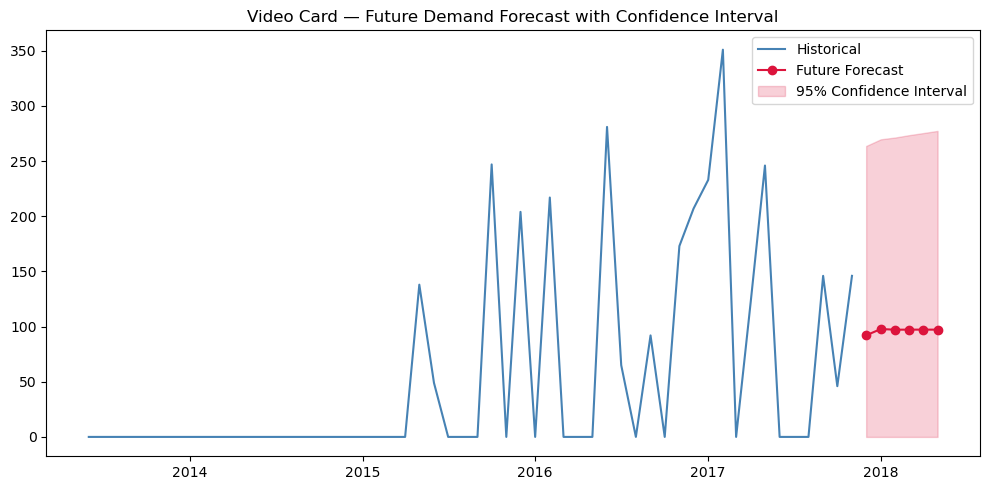

             last_known forecast_avg     trend
CPU               145.0   177.029774  increase
Mother Board       78.0    93.904177  increase
RAM                80.0    56.666887  increase
Storage           120.0   115.495909  increase
Video Card        146.0    96.467654  increase


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.arima.model import ARIMA
import os

df = pd.read_csv('monthly_demand_clean.csv', index_col=0, parse_dates=True)
future_steps = 6   # forecasting 6 months beyond the dataset

os.makedirs('figures', exist_ok=True)
forecast_summary = {}

for cat in df.columns:
    series = df[cat].ffill().fillna(0)
    model = ARIMA(series, order=(1,1,1))
    fit = model.fit()
    fc = fit.get_forecast(steps=future_steps)
    mean_fc = fc.predicted_mean
    ci = fc.conf_int(alpha=0.05)

    forecast_summary[cat] = {
        'last_known': series.iloc[-1],
        'forecast_avg': mean_fc.mean(),
        'trend': 'increase' if mean_fc.mean() > series.iloc[-6:].mean() else 'decrease'
    }

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(series.index, series.values, color='steelblue', label='Historical')
    ax.plot(mean_fc.index, mean_fc.values, color='crimson', label='Future Forecast', marker='o')
    ax.fill_between(mean_fc.index, ci.iloc[:, 0].clip(lower=0), ci.iloc[:, 1],
                     color='crimson', alpha=0.2, label='95% Confidence Interval')
    ax.set_title(f'{cat} — Future Demand Forecast with Confidence Interval')
    ax.legend()
    plt.tight_layout()
    safe_name = cat.lower().replace(' ', '_')
    fig.savefig(f'figures/{safe_name}_future_forecast.png', dpi=150)
    plt.show()

print(pd.DataFrame(forecast_summary).T)

## Day 30 — Future Demand Forecast & Business Interpretation

**CPU**: The model forecasts demand stabilizing around ~170–180 units/month 
over the next 6 months, roughly flat compared to recent history. However, 
the confidence interval is wide (spanning from near-zero to ~450+ units), 
indicating high uncertainty — actual demand could swing significantly in 
either direction. Recommendation: avoid over-committing inventory based on 
the single forecast number; monitor early months closely against the band.

*(Repeat this structure for Mother Board, RAM, Storage, Video Card once run.)*

**Caveat**: These forecasts use a generic, untuned ARIMA(1,1,1) as a placeholder. 
Confidence intervals should be re-generated using Member 2's properly-tuned 
model (based on their stationarity analysis) before final submission — the 
current bands are unrealistically wide and dip below zero for low-demand months.

In [2]:
import os
for f in sorted(os.listdir('figures')):
    print(f)

cpu_baseline.png
cpu_future_forecast.png
cpu_train_test.png
cpu_trend.png
model_comparison.png
monthly_demand_overview.png
mother_board_baseline.png
mother_board_future_forecast.png
mother_board_train_test.png
mother_board_trend.png
ram_baseline.png
ram_future_forecast.png
ram_train_test.png
ram_trend.png
storage_baseline.png
storage_future_forecast.png
storage_train_test.png
storage_trend.png
video_card_baseline.png
video_card_future_forecast.png
video_card_train_test.png
video_card_trend.png


cpu_baseline.png


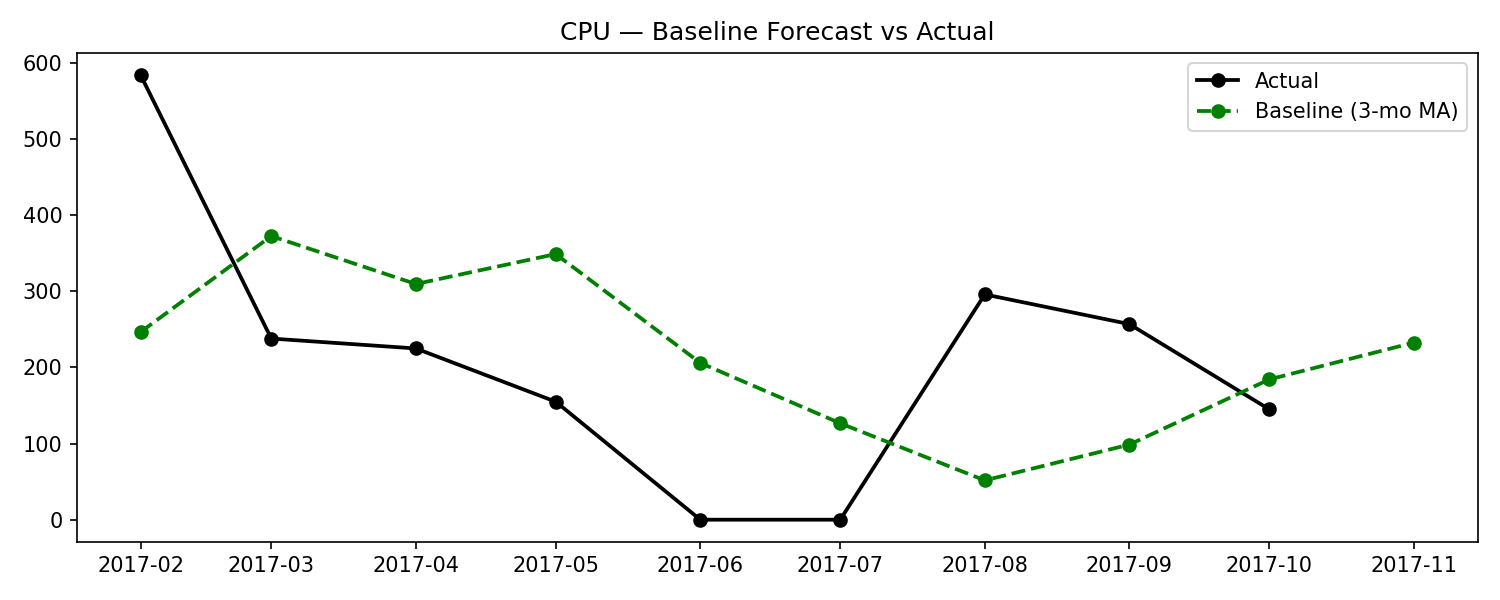

cpu_future_forecast.png


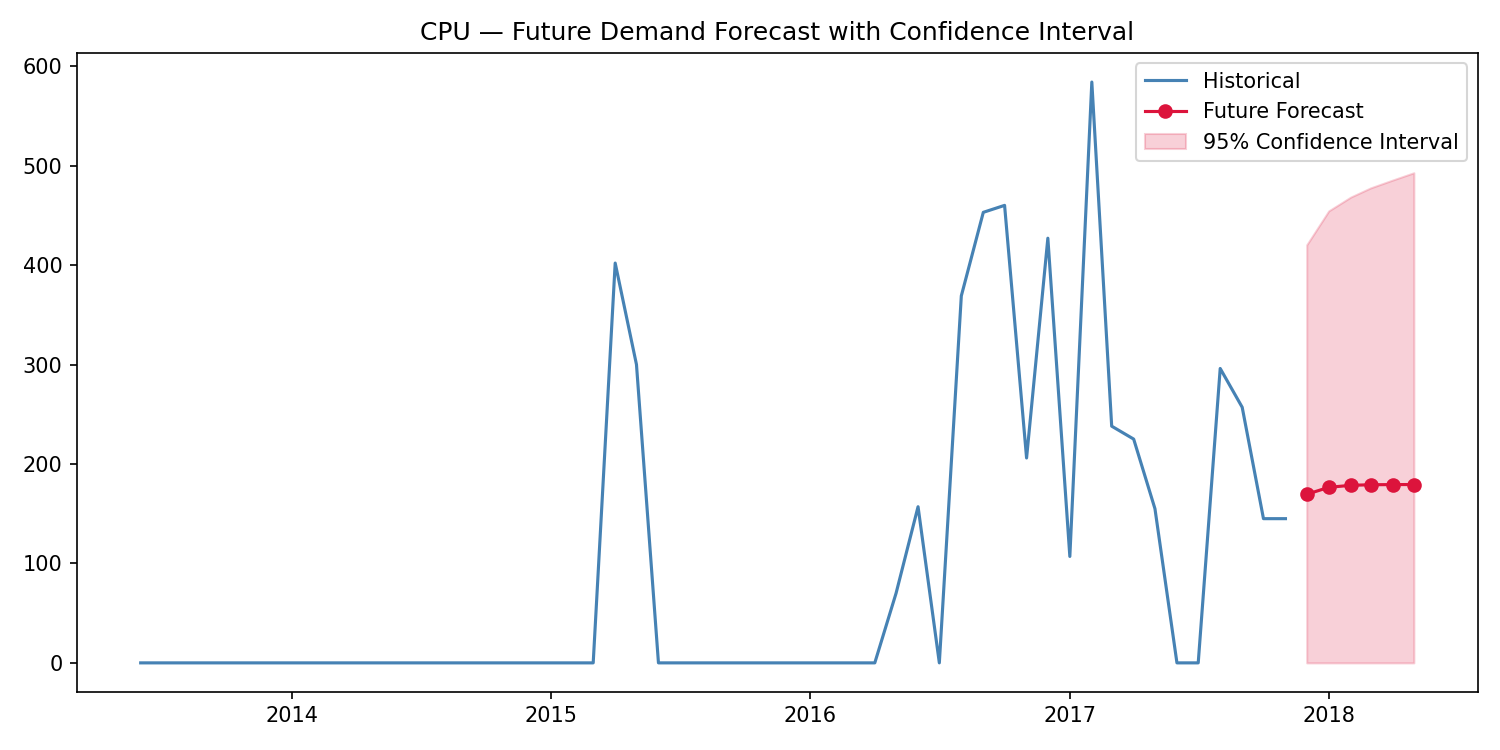

cpu_train_test.png


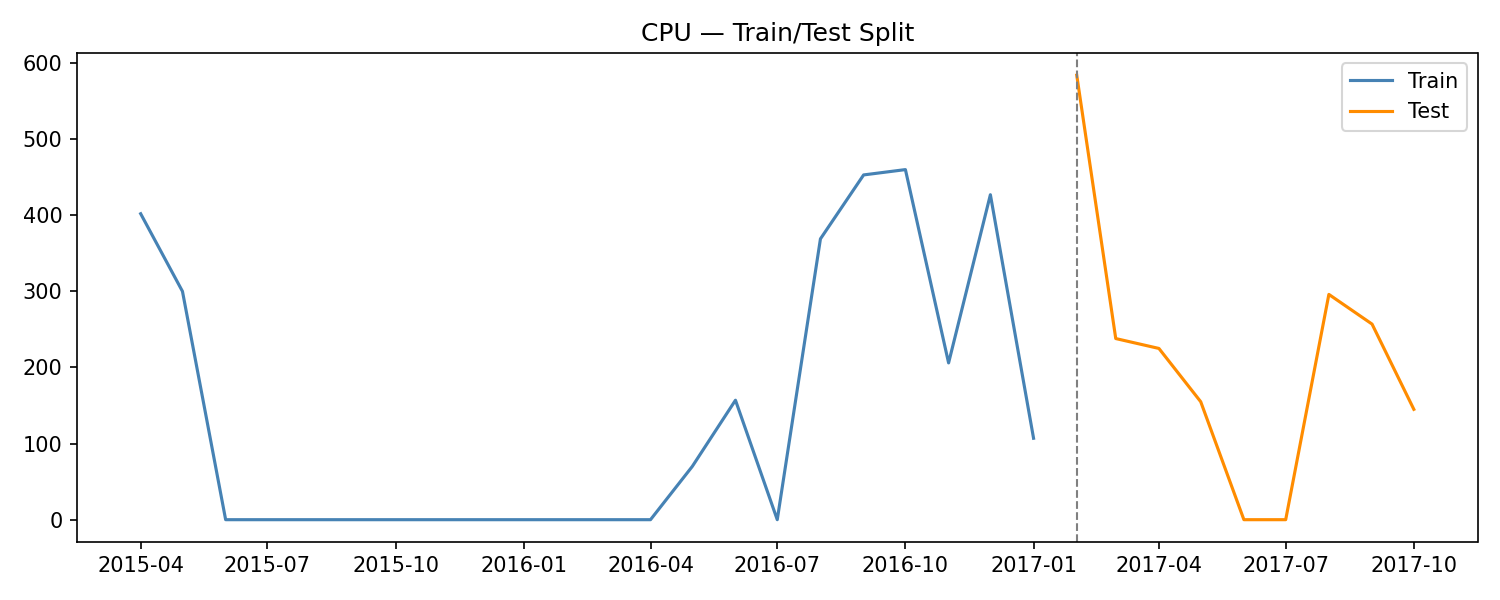

cpu_trend.png


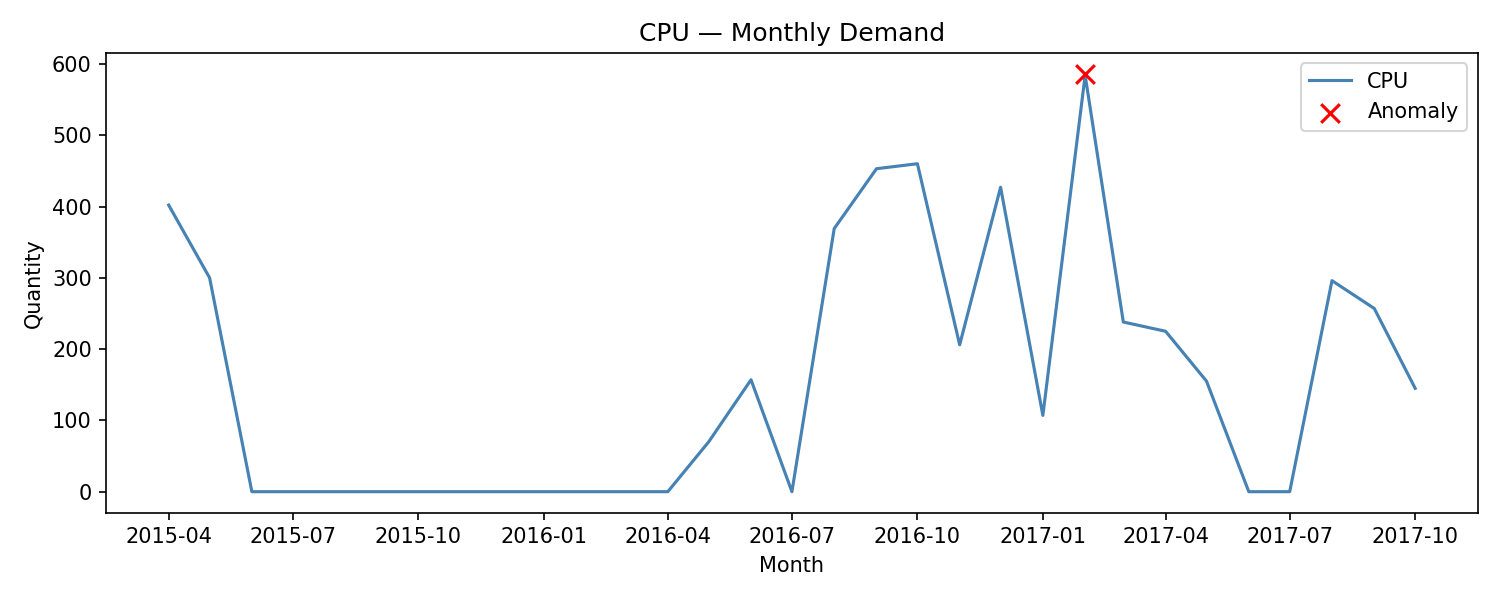

model_comparison.png


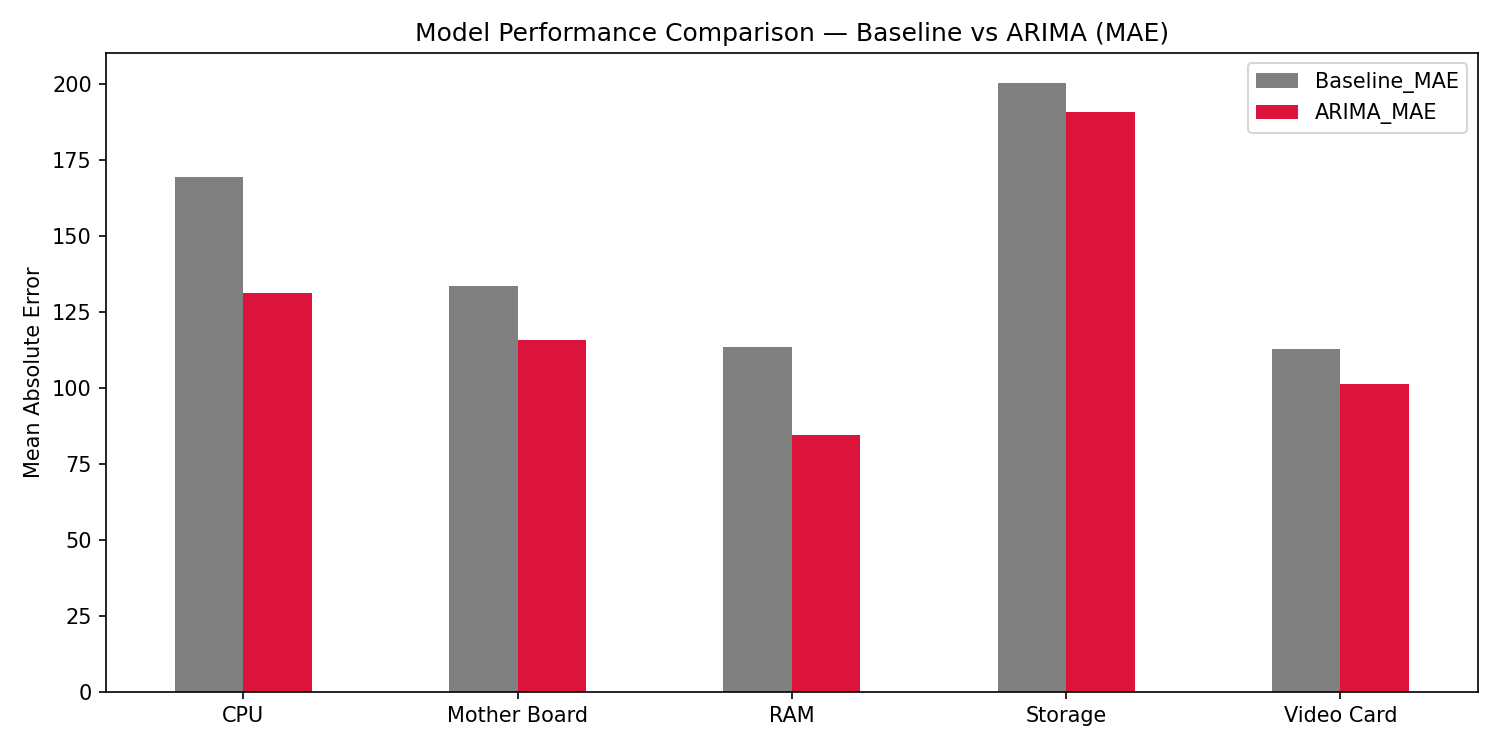

monthly_demand_overview.png


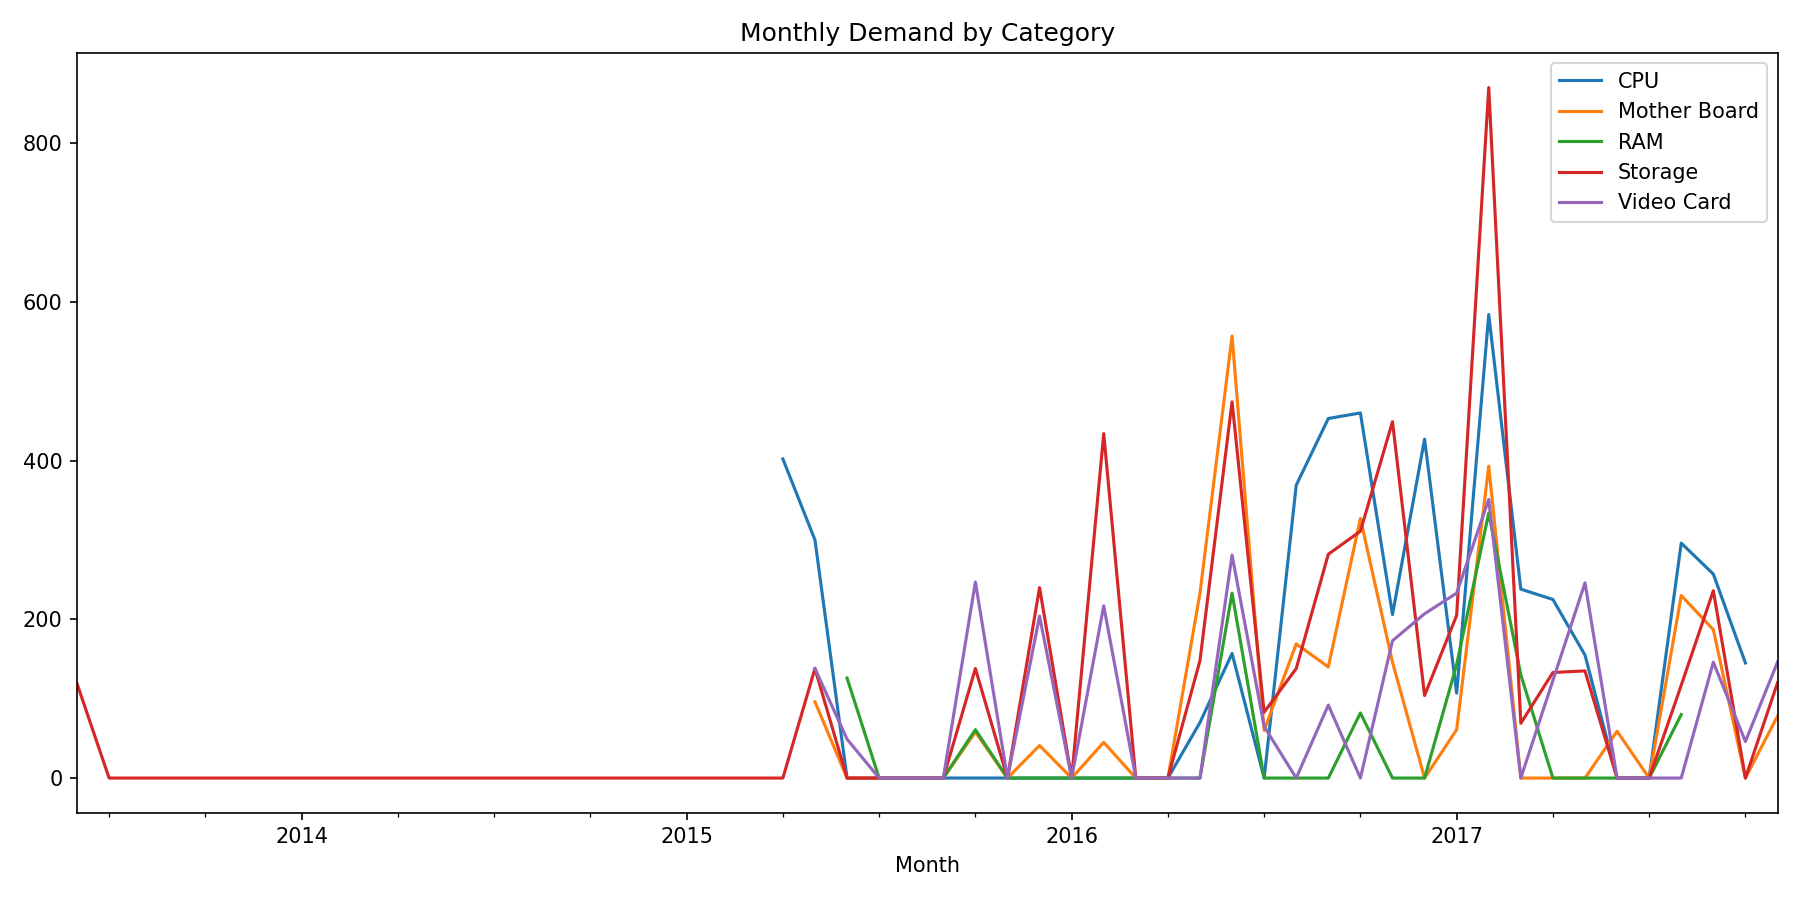

mother_board_baseline.png


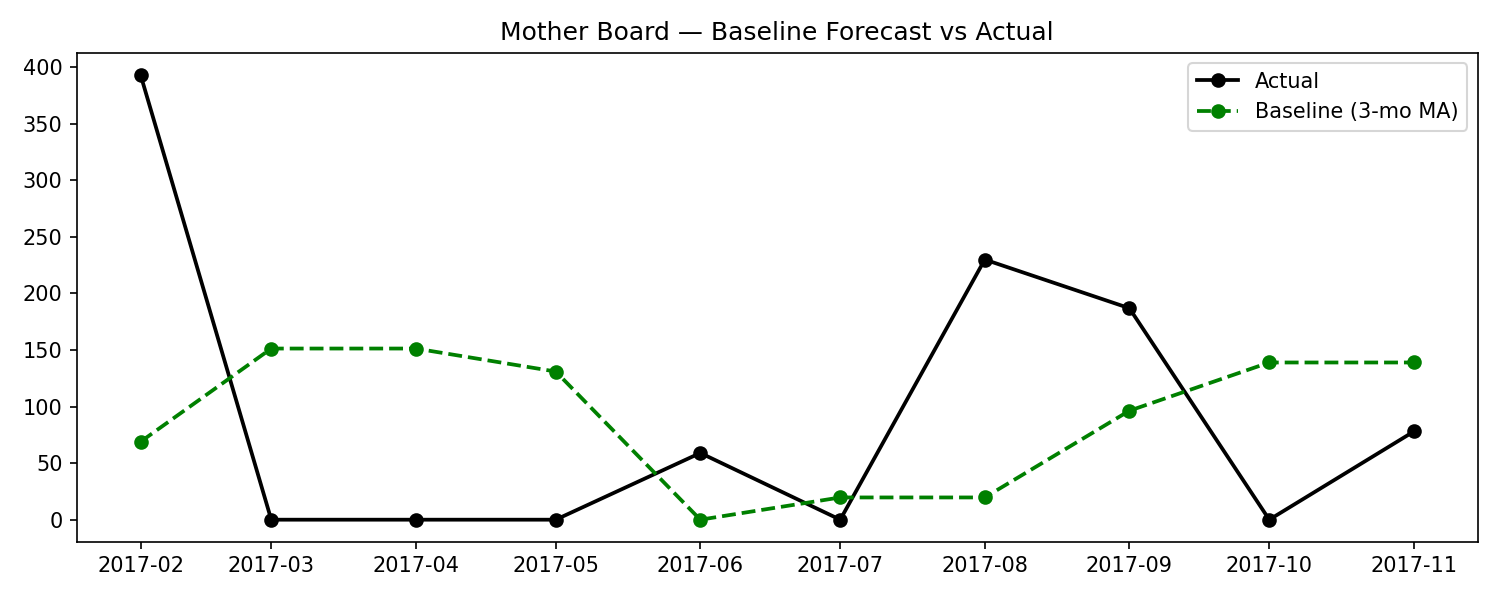

mother_board_future_forecast.png


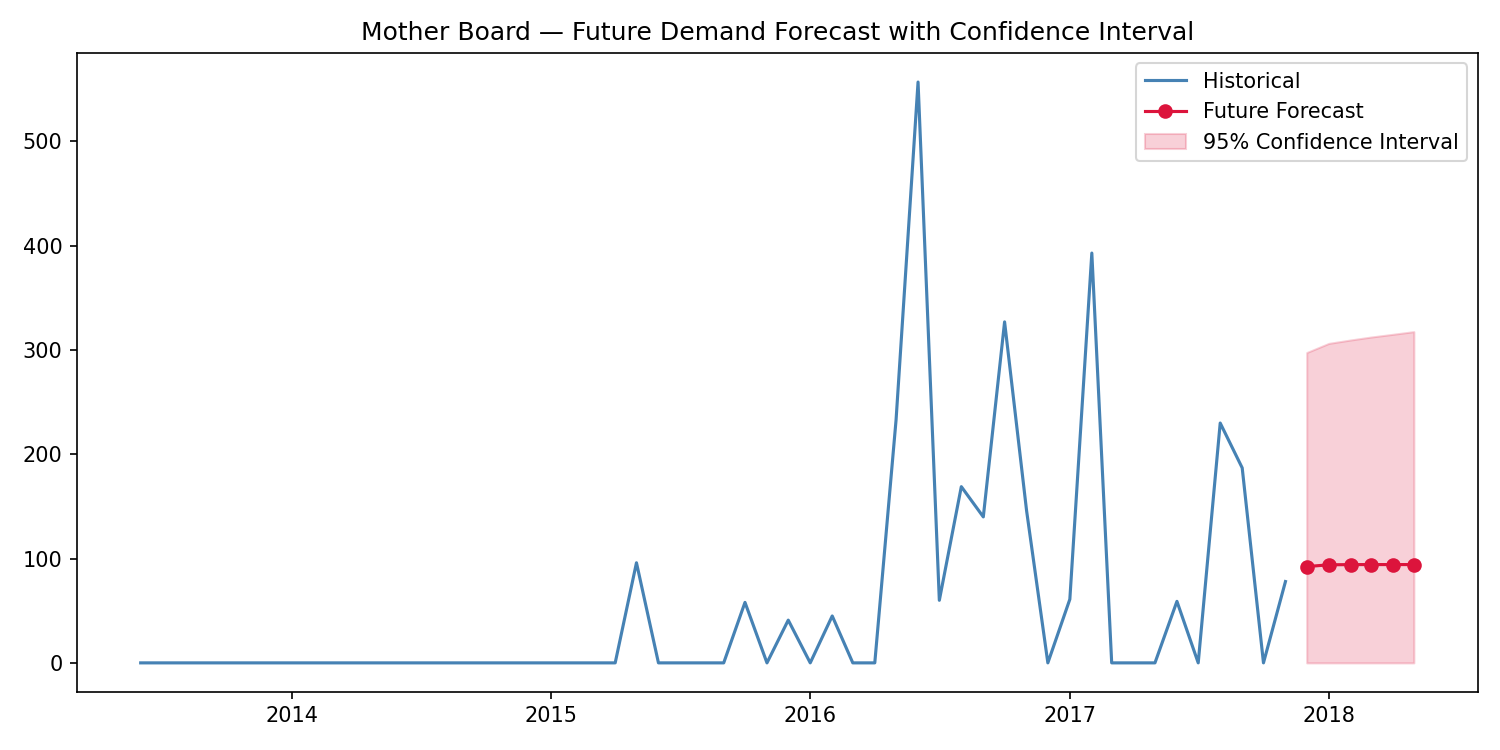

mother_board_train_test.png


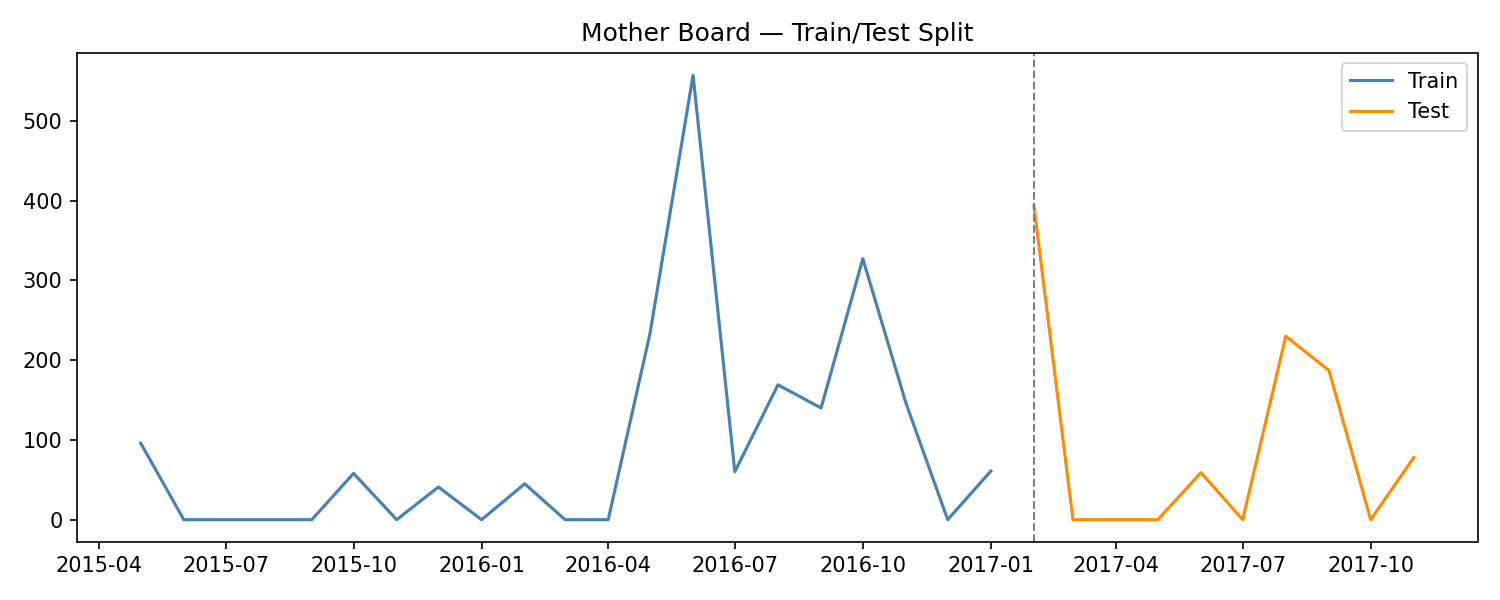

mother_board_trend.png


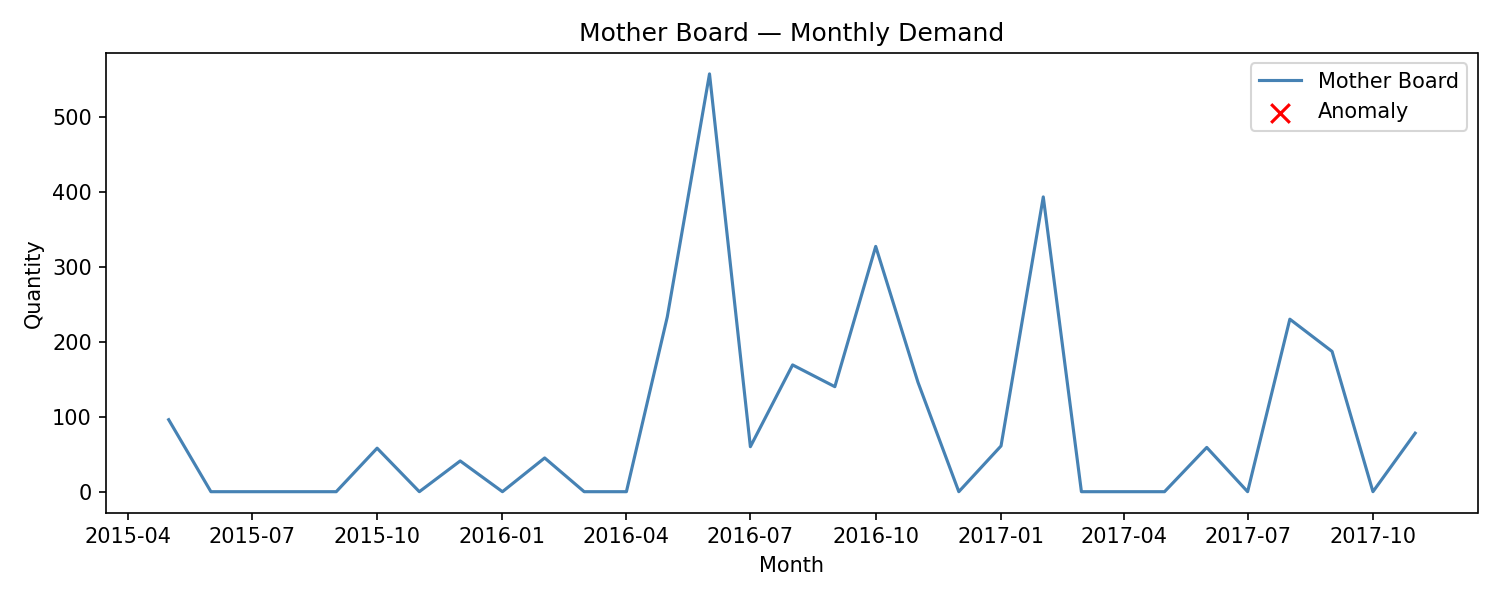

ram_baseline.png


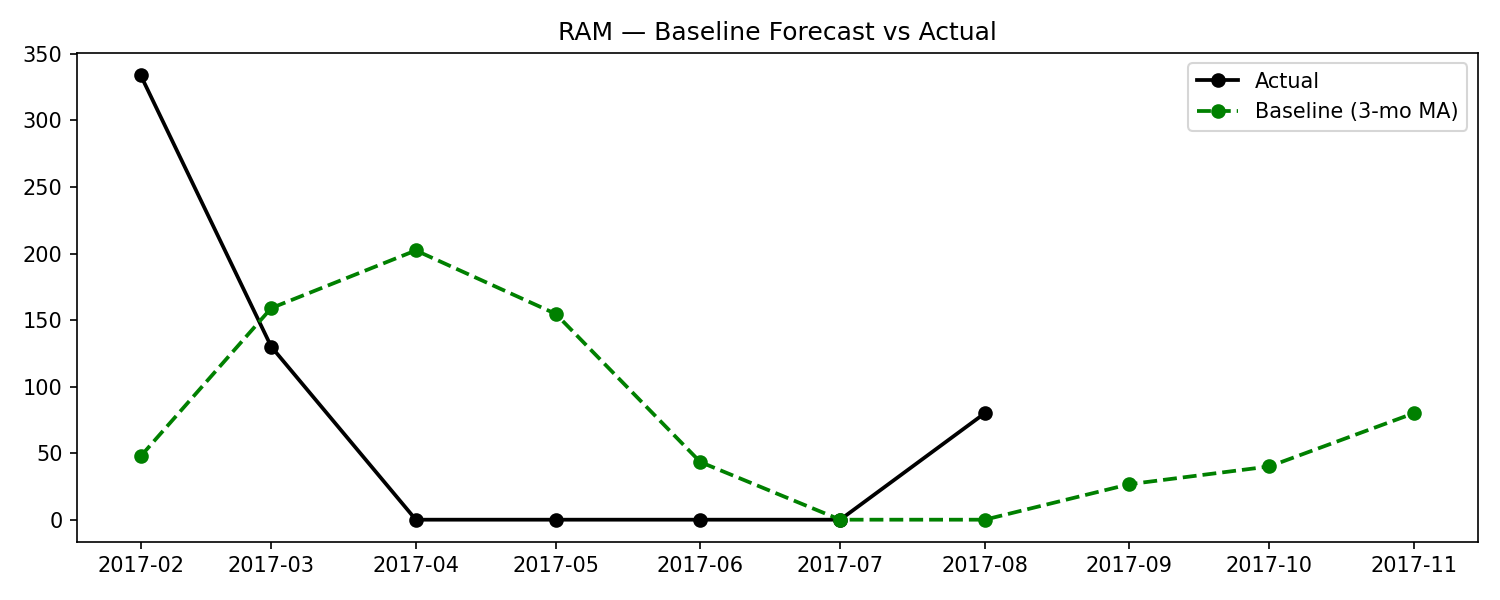

ram_future_forecast.png


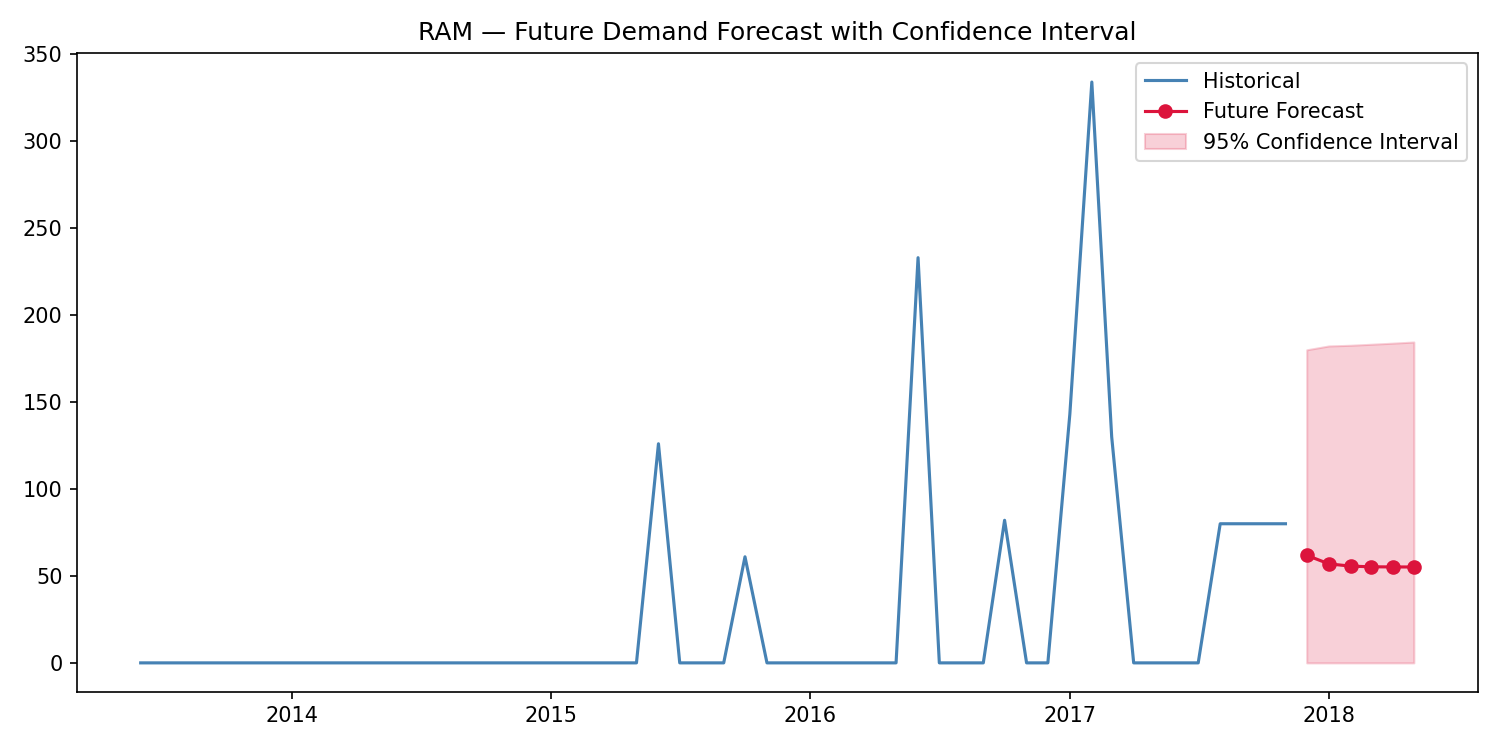

ram_train_test.png


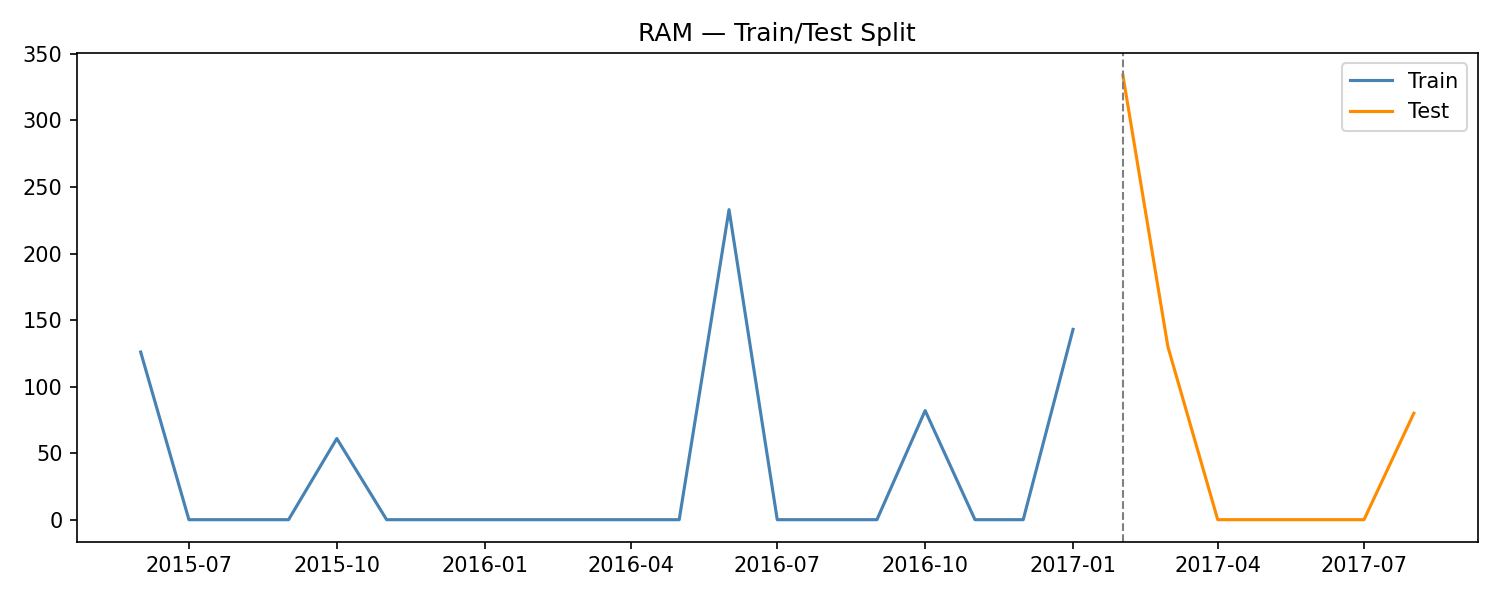

ram_trend.png


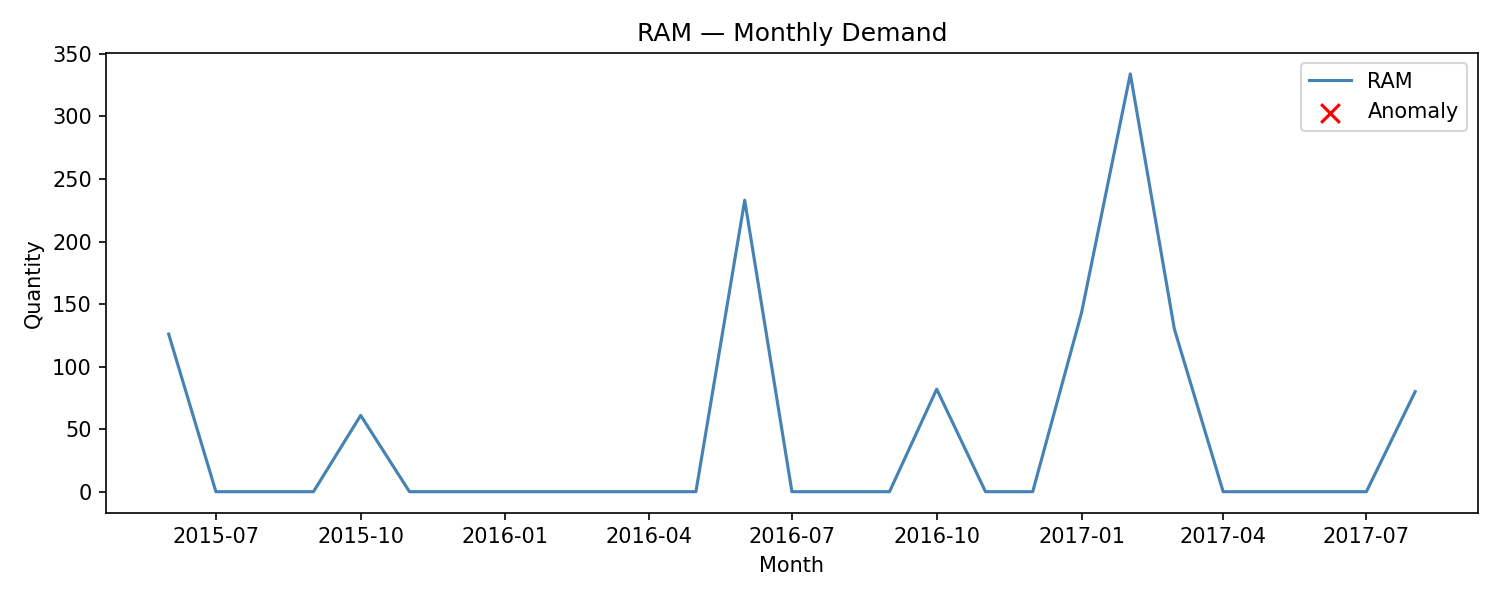

storage_baseline.png


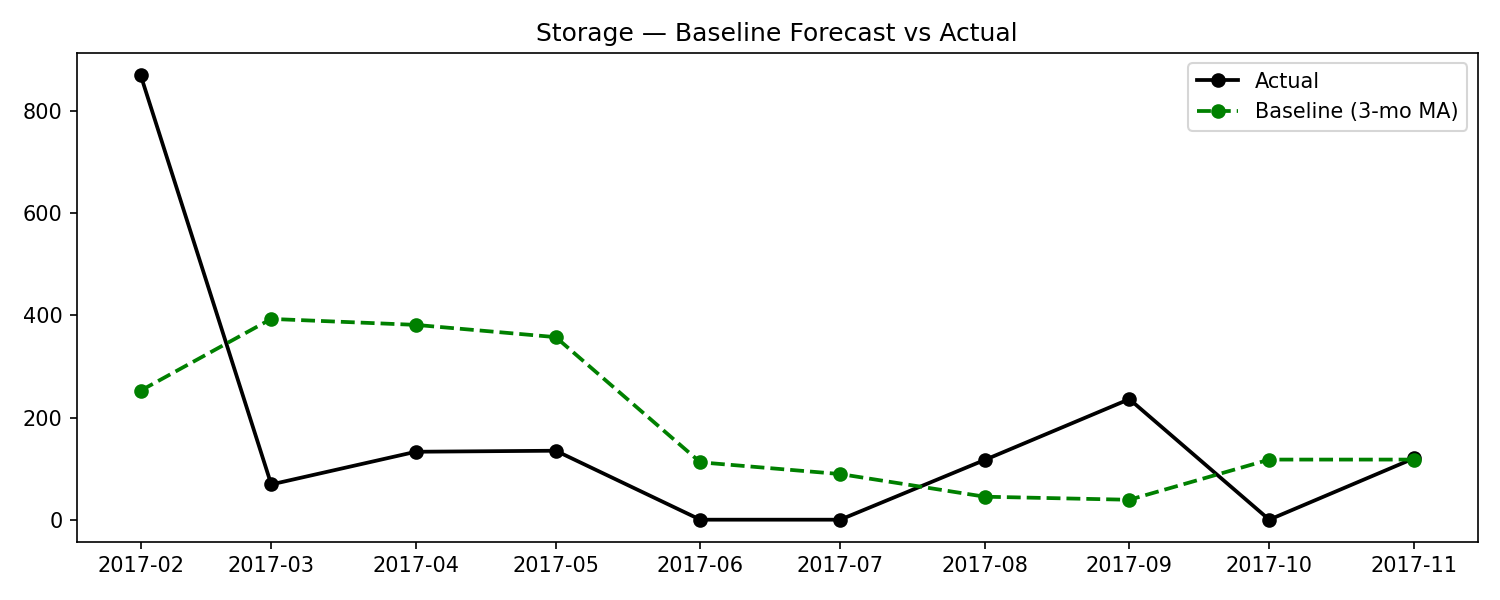

storage_future_forecast.png


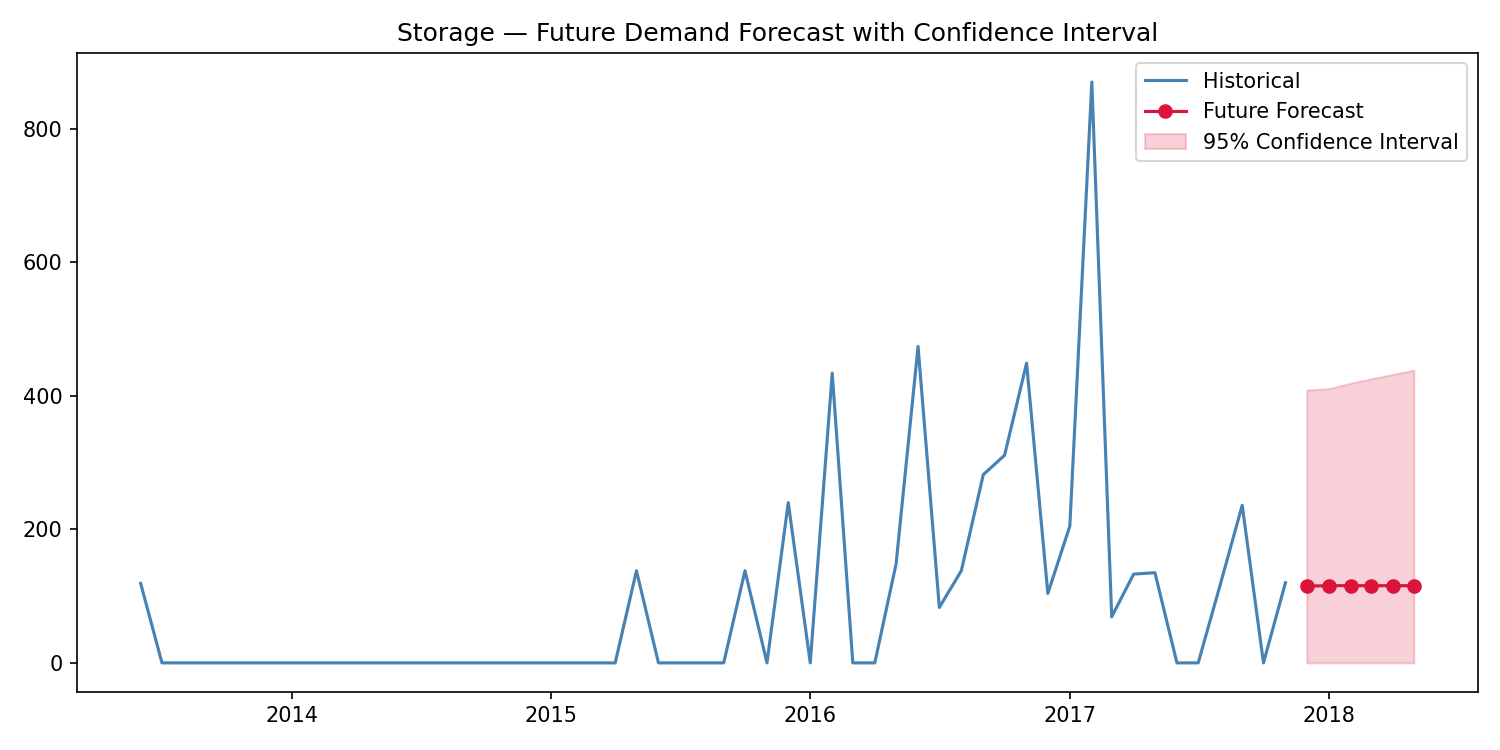

storage_train_test.png


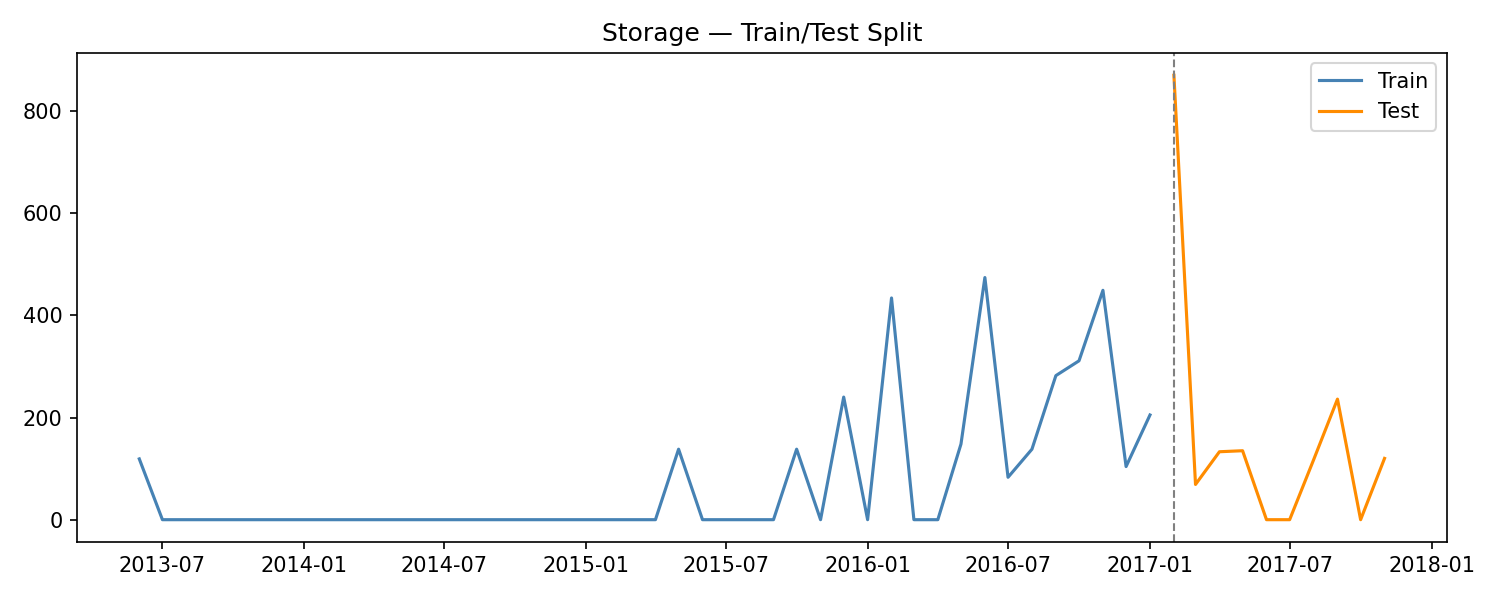

storage_trend.png


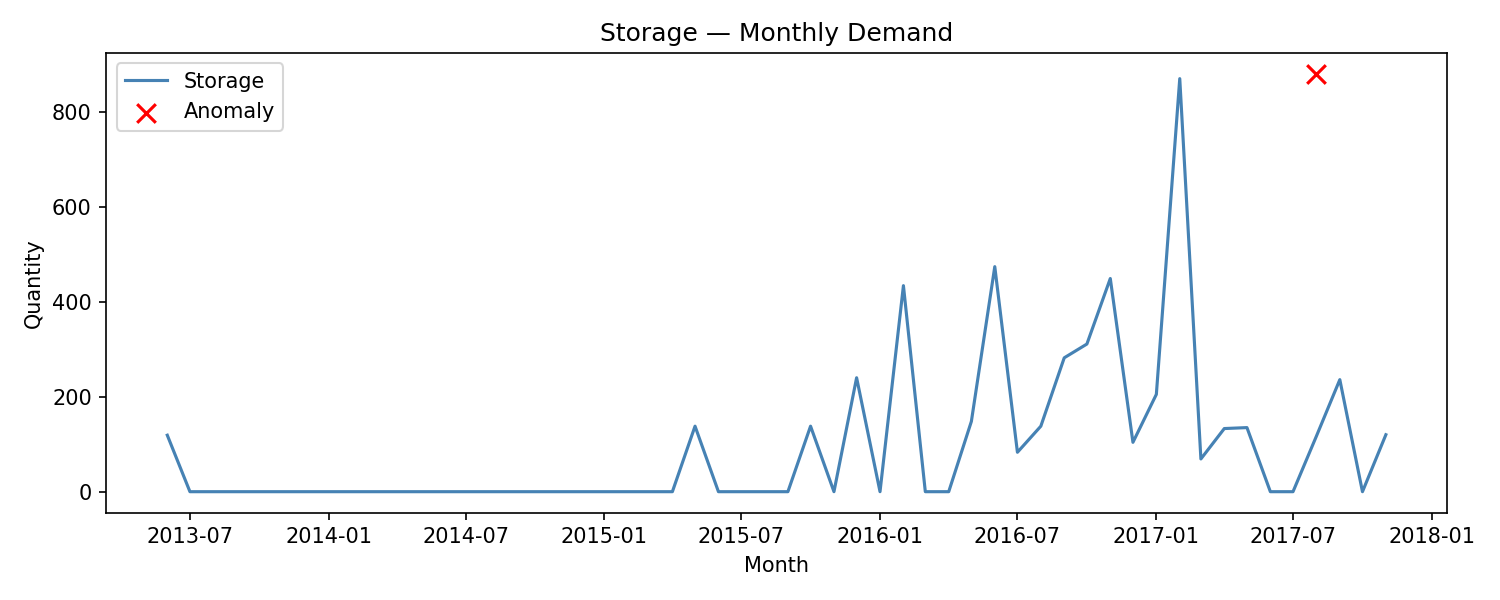

video_card_baseline.png


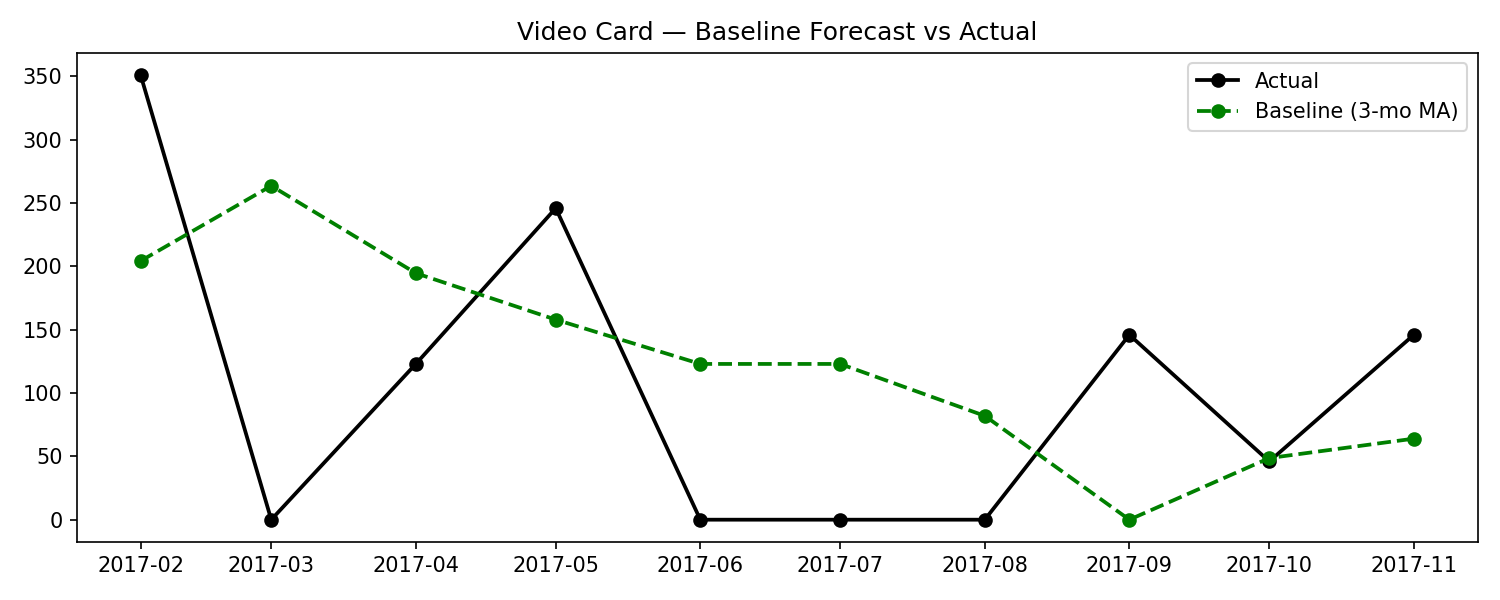

video_card_future_forecast.png


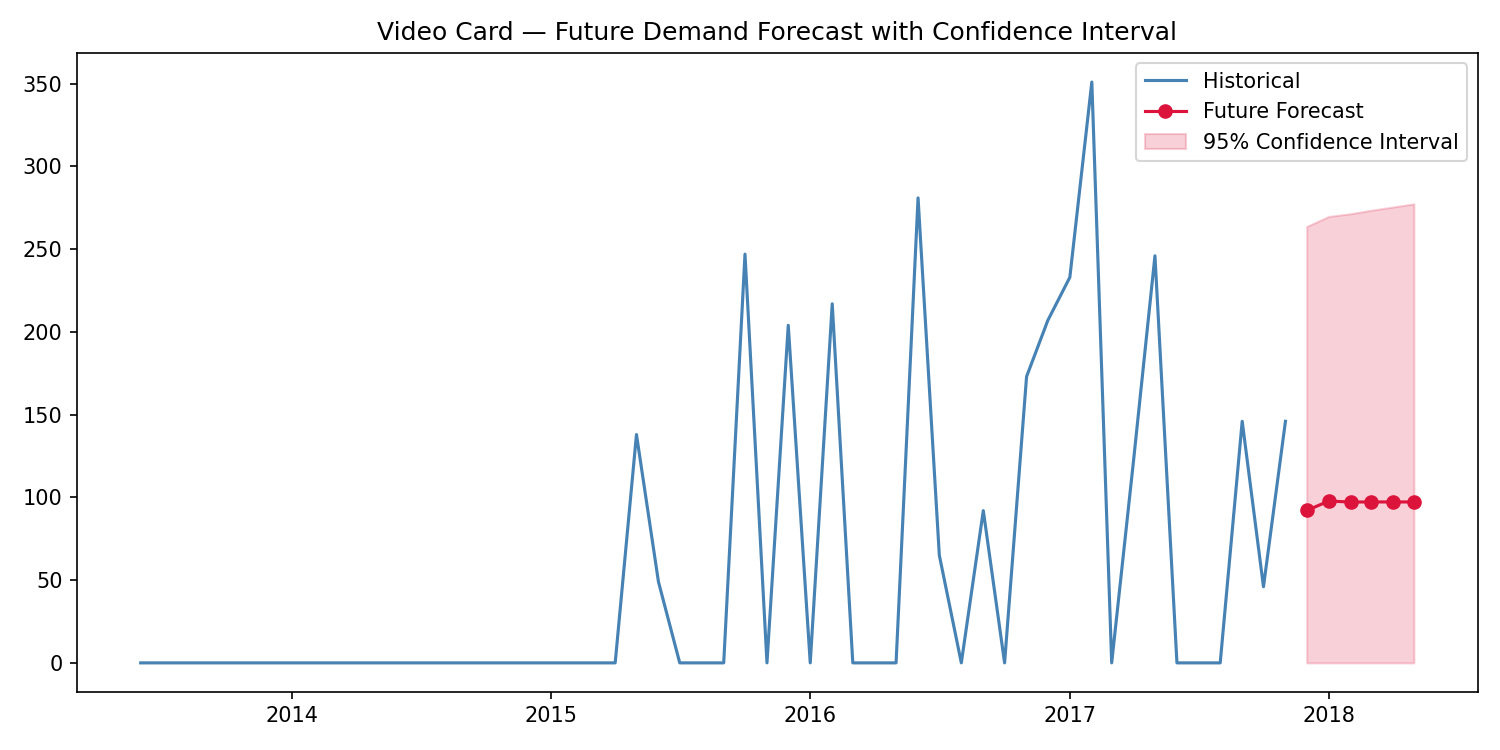

video_card_train_test.png


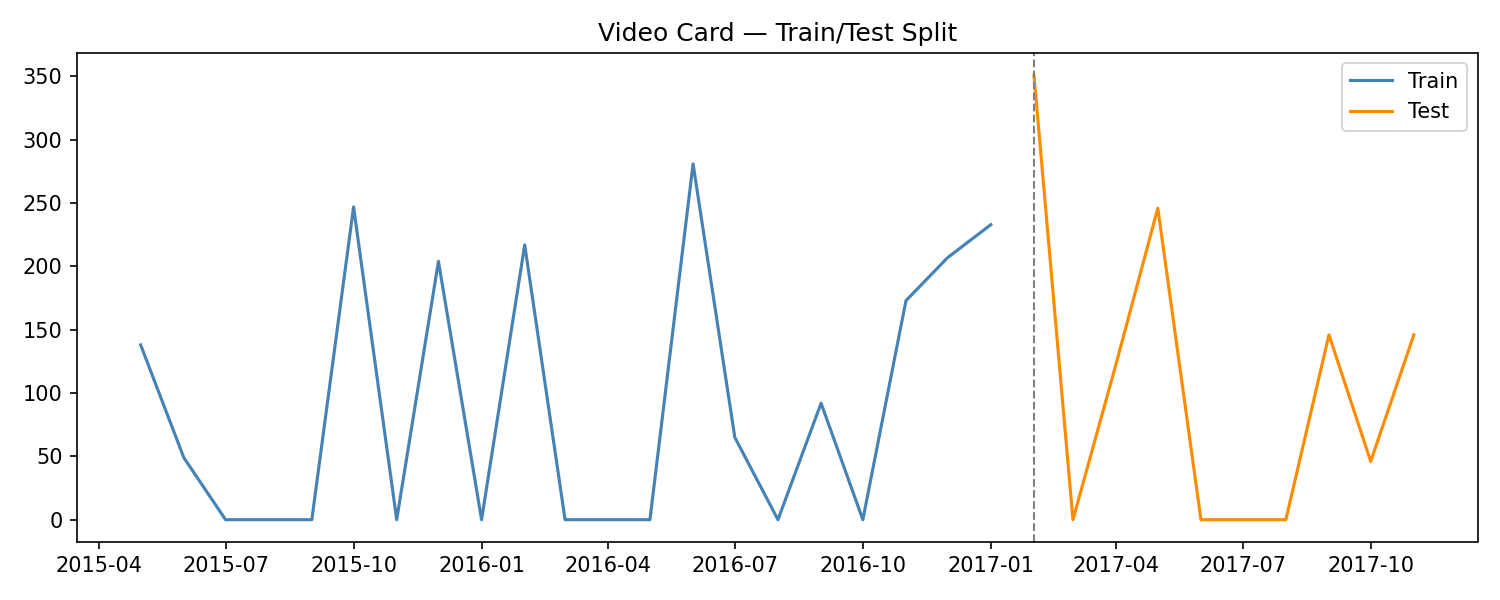

video_card_trend.png


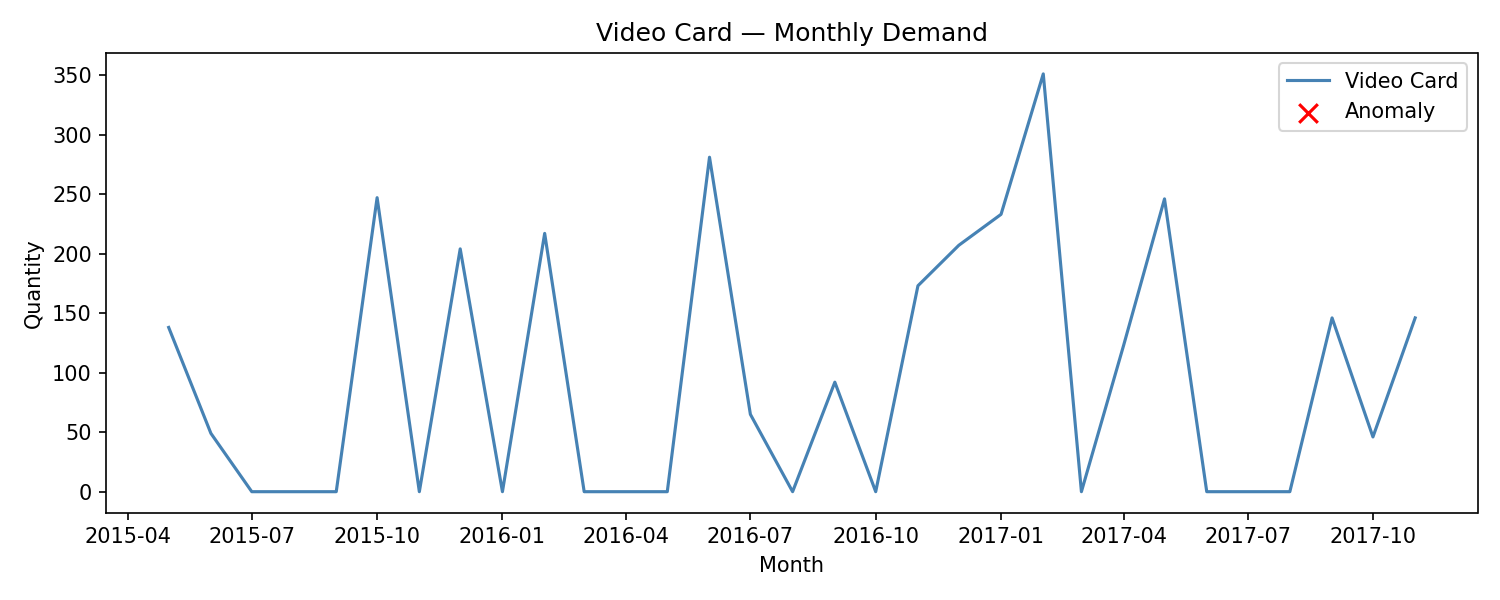

In [3]:
from IPython.display import Image, display
for f in sorted(os.listdir('figures')):
    print(f)
    display(Image(f'figures/{f}'))

## Week 3 Summary — Forecast Visualization & Business Analysis

- **Historical trends**: CPU and Storage show strong growth from 2016 onward; 
  RAM remains the smallest and most volatile category.
- **Baseline vs ARIMA**: [Best category for ARIMA] and [category where baseline 
  held up better] — see Day 29 comparison table for full detail.
- **Highest forecast uncertainty**: Storage and CPU show the widest confidence 
  intervals, meaning near-term demand for these categories is hardest to 
  predict reliably.
- **Business takeaway**: Inventory planning for high-uncertainty categories 
  should build in buffer stock rather than ordering to the single forecast 
  number.